In [2]:
"""
MIT-BIH Arrhythmia data loader + custom 70/30 balanced split
=============================================================

Uses WFDB to read MIT-BIH directly from PhysioNet.
NO manual dataset download and NO local dataset storage.

Labels:
    0 = Normal beat
    1 = Arrhythmia present

Split:
    - 70% of TOTAL data -> training
    - 30% -> testing
    - Training = exactly 35% class-0 + 35% class-1 of TOTAL
    - If class-1 is insufficient, training minority samples are
      randomly duplicated.
    - Test contains only real samples.

Install:
    pip install wfdb numpy
"""

import numpy as np
import wfdb


# ----------------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------------

RECORD_LIST = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108',
    '109', '111', '112', '113', '114', '115', '116', '117', '118',
    '119', '121', '122', '123', '124', '200', '201', '202', '203',
    '205', '207', '208', '209', '210', '212', '213', '214', '215',
    '217', '219', '220', '221', '222', '223', '228', '230', '231',
    '232', '233', '234'
]

HALF_WIN = 90
TRAIN_FRAC_PER_CLASS = 0.35
RANDOM_STATE = 42

NORMAL_SYMBOLS = {'N', 'L', 'R', 'e', 'j'}

ARRHYTHMIA_SYMBOLS = {
    'V', 'A', 'F', 'f', 'J', 'S',
    'E', '/', 'Q', 'a', 'x'
}


# ----------------------------------------------------------------------------
# EXTRACT BEATS DIRECTLY FROM PHYSIONET
# ----------------------------------------------------------------------------

def extract_beats():

    X = []
    y = []

    for rec_name in RECORD_LIST:

        print(f"Processing record {rec_name}...")

        try:
            # Read directly from PhysioNet
            record = wfdb.rdrecord(
                rec_name,
                pn_dir='mitdb'
            )

            annotation = wfdb.rdann(
                rec_name,
                'atr',
                pn_dir='mitdb'
            )

        except Exception as e:
            print(f"Skipping {rec_name}: {e}")
            continue

        # First ECG channel
        signal = record.p_signal[:, 0]

        for sym, sample in zip(
            annotation.symbol,
            annotation.sample
        ):

            # Ignore symbols that are not part of our binary classes
            if (
                sym not in NORMAL_SYMBOLS
                and sym not in ARRHYTHMIA_SYMBOLS
            ):
                continue

            # Make sure complete 180-sample window exists
            if sample - HALF_WIN < 0:
                continue

            if sample + HALF_WIN > len(signal):
                continue

            # 180-sample ECG beat
            beat = signal[
                sample - HALF_WIN:
                sample + HALF_WIN
            ]

            # Binary label
            if sym in NORMAL_SYMBOLS:
                label = 0
            else:
                label = 1

            X.append(beat)
            y.append(label)

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.int64)

    return X, y


# ----------------------------------------------------------------------------
# CUSTOM 70/30 SPLIT
# ----------------------------------------------------------------------------

def custom_balanced_split(
    X,
    y,
    train_frac_per_class=TRAIN_FRAC_PER_CLASS,
    random_state=RANDOM_STATE
):

    rng = np.random.RandomState(random_state)

    n_total = len(y)

    # 35% of TOTAL for each class
    target_per_class = int(
        train_frac_per_class * n_total
    )

    # Find indices
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]

    # Shuffle
    rng.shuffle(idx0)
    rng.shuffle(idx1)

    # ------------------------------------------------------------------------
    # CLASS 0
    # ------------------------------------------------------------------------

    if len(idx0) >= target_per_class:

        train_idx0 = idx0[:target_per_class]
        test_idx0 = idx0[target_per_class:]

    else:

        train_idx0 = idx0
        test_idx0 = np.array([], dtype=int)


    # ------------------------------------------------------------------------
    # CLASS 1
    # ------------------------------------------------------------------------

    if len(idx1) >= target_per_class:

        train_idx1 = idx1[:target_per_class]
        test_idx1 = idx1[target_per_class:]

    else:

        # Use 70% of real minority samples for training
        split_point = int(0.70 * len(idx1))

        train_idx1 = idx1[:split_point]
        test_idx1 = idx1[split_point:]

        # Need oversampling
        shortfall = target_per_class - len(train_idx1)

        if shortfall > 0:

            extra_idx1 = rng.choice(
                train_idx1,
                size=shortfall,
                replace=True
            )

            train_idx1 = np.concatenate([
                train_idx1,
                extra_idx1
            ])


    # ------------------------------------------------------------------------
    # BUILD TRAIN / TEST
    # ------------------------------------------------------------------------

    X_train = np.concatenate([
        X[train_idx0],
        X[train_idx1]
    ])

    y_train = np.concatenate([
        y[train_idx0],
        y[train_idx1]
    ])

    X_test = np.concatenate([
        X[test_idx0],
        X[test_idx1]
    ])

    y_test = np.concatenate([
        y[test_idx0],
        y[test_idx1]
    ])


    # Shuffle training set
    train_perm = rng.permutation(len(y_train))

    X_train = X_train[train_perm]
    y_train = y_train[train_perm]


    # Shuffle test set
    test_perm = rng.permutation(len(y_test))

    X_test = X_test[test_perm]
    y_test = y_test[test_perm]


    return (
        X_train,
        X_test,
        y_train,
        y_test
    )


# ----------------------------------------------------------------------------
# MAIN
# ----------------------------------------------------------------------------

if __name__ == "__main__":

    print("=" * 70)
    print("MIT-BIH ARRHYTHMIA DATASET")
    print("Direct PhysioNet access using WFDB")
    print("=" * 70)

    # ------------------------------------------------------------------------
    # Extract directly from PhysioNet
    # ------------------------------------------------------------------------

    X, y = extract_beats()

    print("\nDataset extracted")

    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")

    print(
        f"Total samples : {len(y)}"
    )

    print(
        f"Class 0       : {np.sum(y == 0)}"
    )

    print(
        f"Class 1       : {np.sum(y == 1)}"
    )


    # ------------------------------------------------------------------------
    # Split
    # ------------------------------------------------------------------------

    X_train, X_test, y_train, y_test = \
        custom_balanced_split(X, y)


    # ------------------------------------------------------------------------
    # Results
    # ------------------------------------------------------------------------

    print("\n" + "=" * 70)
    print("FINAL SPLIT")
    print("=" * 70)

    print(
        f"Train samples : {len(y_train)}"
    )

    print(
        f"  Class 0     : {np.sum(y_train == 0)}"
    )

    print(
        f"  Class 1     : {np.sum(y_train == 1)}"
    )

    print(
        f"  Class ratio : "
        f"{np.mean(y_train == 0):.2%} / "
        f"{np.mean(y_train == 1):.2%}"
    )


    print()

    print(
        f"Test samples  : {len(y_test)}"
    )

    print(
        f"  Class 0     : {np.sum(y_test == 0)}"
    )

    print(
        f"  Class 1     : {np.sum(y_test == 1)}"
    )

    print(
        f"  Class ratio : "
        f"{np.mean(y_test == 0):.2%} / "
        f"{np.mean(y_test == 1):.2%}"
    )


    print("\nShapes:")
    print(f"X_train: {X_train.shape}")
    print(f"y_train: {y_train.shape}")
    print(f"X_test : {X_test.shape}")
    print(f"y_test : {y_test.shape}")

MIT-BIH ARRHYTHMIA DATASET
Direct PhysioNet access using WFDB
Processing record 100...
Processing record 101...
Processing record 102...
Processing record 103...
Processing record 104...
Processing record 105...
Processing record 106...
Processing record 107...
Processing record 108...
Processing record 109...
Processing record 111...
Processing record 112...
Processing record 113...
Processing record 114...
Processing record 115...
Processing record 116...
Processing record 117...
Processing record 118...
Processing record 119...
Processing record 121...
Processing record 122...
Processing record 123...
Processing record 124...
Processing record 200...
Processing record 201...
Processing record 202...
Processing record 203...
Processing record 205...
Processing record 207...
Processing record 208...
Processing record 209...
Processing record 210...
Processing record 212...
Processing record 213...
Processing record 214...
Processing record 215...
Processing record 217...
Processing re

In [3]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

# ============================================================
# 1. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# 2. TRAIN / VALIDATION SPLIT
# ============================================================
# Your current data:
#
# X_train = (76762, 180)
# y_train = (76762,)
#
# X_test  = (57943, 180)
# y_test  = (57943,)
#
# We take 15% of X_train for validation.
# X_test remains completely untouched.

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

print("\nDATA SPLIT")
print("=" * 60)

print("Training:")
print("  Samples:", len(y_tr))
print("  Class 0:", np.sum(y_tr == 0))
print("  Class 1:", np.sum(y_tr == 1))

print("\nValidation:")
print("  Samples:", len(y_val))
print("  Class 0:", np.sum(y_val == 0))
print("  Class 1:", np.sum(y_val == 1))

print("\nFinal Test:")
print("  Samples:", len(y_test))
print("  Class 0:", np.sum(y_test == 0))
print("  Class 1:", np.sum(y_test == 1))


# ============================================================
# 3. CONVERT TO PYTORCH FORMAT
# ============================================================
# Conv1D expects:
# (batch, channels, length)
#
# Current:
# (batch, 180)
#
# Required:
# (batch, 1, 180)

X_tr = torch.tensor(
    X_tr,
    dtype=torch.float32
).unsqueeze(1)

X_val = torch.tensor(
    X_val,
    dtype=torch.float32
).unsqueeze(1)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
).unsqueeze(1)

y_tr = torch.tensor(
    y_tr,
    dtype=torch.float32
)

y_val = torch.tensor(
    y_val,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
)


# ============================================================
# 4. DATA LOADERS
# ============================================================

BATCH_SIZE = 128

train_dataset = TensorDataset(
    X_tr,
    y_tr
)

val_dataset = TensorDataset(
    X_val,
    y_val
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# 5. HARDWARE-FRIENDLY 1D CNN
# ============================================================

class ECGHardwareCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            # Input: 1 x 180
            nn.Conv1d(
                in_channels=1,
                out_channels=8,
                kernel_size=5,
                padding=2
            ),

            # 8 x 180
            nn.ReLU(),

            # 8 x 90
            nn.MaxPool1d(kernel_size=2),


            # 8 x 90
            nn.Conv1d(
                in_channels=8,
                out_channels=16,
                kernel_size=5,
                padding=2
            ),

            # 16 x 90
            nn.ReLU(),

            # 16 x 45
            nn.MaxPool1d(kernel_size=2)
        )

        self.classifier = nn.Sequential(

            # 16 * 45 = 720
            nn.Linear(16 * 45, 32),

            nn.ReLU(),

            nn.Linear(32, 1)
        )


    def forward(self, x):

        x = self.features(x)

        # Flatten
        x = x.view(x.size(0), -1)

        x = self.classifier(x)

        return x.squeeze(1)


# ============================================================
# 6. CREATE MODEL
# ============================================================

model = ECGHardwareCNN().to(device)

print("\nMODEL")
print("=" * 60)
print(model)


# ============================================================
# 7. LOSS + OPTIMIZER
# ============================================================

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


# ============================================================
# 8. TRAINING FUNCTIONS
# ============================================================

def train_one_epoch(model, loader):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)

        loss = criterion(
            logits,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * len(y_batch)

        predictions = (
            torch.sigmoid(logits) >= 0.5
        ).float()

        correct += (
            predictions == y_batch
        ).sum().item()

        total += len(y_batch)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy


# ============================================================
# VALIDATION
# ============================================================

def validate(model, loader):

    model.eval()

    total_loss = 0
    total = 0

    all_targets = []
    all_probs = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)

            loss = criterion(
                logits,
                y_batch
            )

            total_loss += loss.item() * len(y_batch)
            total += len(y_batch)

            probs = torch.sigmoid(logits)

            all_probs.extend(
                probs.cpu().numpy()
            )

            all_targets.extend(
                y_batch.cpu().numpy()
            )

    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)

    predictions = (
        all_probs >= 0.5
    ).astype(int)

    loss = total_loss / total

    accuracy = accuracy_score(
        all_targets,
        predictions
    )

    f1 = f1_score(
        all_targets,
        predictions,
        zero_division=0
    )

    auc = roc_auc_score(
        all_targets,
        all_probs
    )

    return loss, accuracy, f1, auc


# ============================================================
# 9. TRAINING
# ============================================================

EPOCHS = 20
PATIENCE = 4

best_val_loss = float("inf")
patience_counter = 0

print("\nTRAINING")
print("=" * 80)

for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc, val_f1, val_auc = validate(
        model,
        val_loader
    )

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"Val F1: {val_f1:.4f} | "
        f"Val AUC: {val_auc:.4f}"
    )

    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_ecg_hardware_cnn.pth"
        )

        patience_counter = 0

        print("  -> Best model saved")

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:

            print("\nEarly stopping.")

            break


# ============================================================
# 10. LOAD BEST MODEL
# ============================================================

model.load_state_dict(
    torch.load(
        "best_ecg_hardware_cnn.pth",
        map_location=device
    )
)

model.eval()


# ============================================================
# 11. FINAL TEST
# ============================================================
# IMPORTANT:
# This test set was NOT used for training or model selection.

def evaluate_test(model, loader):

    model.eval()

    all_targets = []
    all_probs = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)

            logits = model(X_batch)

            probs = torch.sigmoid(logits)

            all_probs.extend(
                probs.cpu().numpy()
            )

            all_targets.extend(
                y_batch.numpy()
            )

    all_targets = np.array(all_targets)
    all_probs = np.array(all_probs)

    predictions = (
        all_probs >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        all_targets,
        predictions
    )

    precision = precision_score(
        all_targets,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        all_targets,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        all_targets,
        predictions,
        zero_division=0
    )

    auc = roc_auc_score(
        all_targets,
        all_probs
    )

    cm = confusion_matrix(
        all_targets,
        predictions
    )

    return (
        accuracy,
        precision,
        recall,
        f1,
        auc,
        cm
    )


# ============================================================
# 12. FINAL RESULTS
# ============================================================

accuracy, precision, recall, f1, auc, cm = \
    evaluate_test(
        model,
        test_loader
    )

print("\n")
print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(
    f"Accuracy    : {accuracy*100:.2f}%"
)

print(
    f"Precision   : {precision*100:.2f}%"
)

print(
    f"Sensitivity : {recall*100:.2f}%"
)

print(
    f"F1 Score    : {f1*100:.2f}%"
)

print(
    f"ROC-AUC     : {auc:.4f}"
)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# 13. MODEL PARAMETERS
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nMODEL SIZE")
print("=" * 60)

print(
    "Total parameters:",
    total_params
)

print(
    "Trainable parameters:",
    trainable_params
)


# ============================================================
# 14. TEST ONE SMALL SAMPLE
# ============================================================

print("\nSINGLE SAMPLE TEST")
print("=" * 60)

sample_index = 0

sample = X_test_tensor[
    sample_index
].unsqueeze(0).to(device)

actual = int(
    y_test_tensor[sample_index].item()
)

with torch.no_grad():

    output = model(sample)

    probability = torch.sigmoid(
        output
    ).item()

prediction = int(
    probability >= 0.5
)

print("Actual     :", actual)
print("Prediction :", prediction)
print(
    "Probability:",
    f"{probability:.4f}"
)

if prediction == 0:
    print("Result     : NORMAL")
else:
    print("Result     : ARRHYTHMIA")


# ============================================================
# 15. SAVE FINAL MODEL
# ============================================================

torch.save(
    model.state_dict(),
    "ecg_hardware_cnn_fp32.pth"
)

print("\nSaved:")
print("  best_ecg_hardware_cnn.pth")
print("  ecg_hardware_cnn_fp32.pth")

Device: cuda

DATA SPLIT
Training:
  Samples: 65247
  Class 0: 32623
  Class 1: 32624

Validation:
  Samples: 11515
  Class 0: 5758
  Class 1: 5757

Final Test:
  Samples: 57943
  Class 0: 52227
  Class 1: 5716

MODEL
ECGHardwareCNN(
  (features): Sequential(
    (0): Conv1d(1, 8, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(8, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=720, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

TRAINING
Epoch [01/20] | Train Loss: 0.3551 | Train Acc: 84.47% | Val Loss: 0.2643 | Val Acc: 89.74% | Val F1: 0.8903 | Val AUC: 0.9528
  -> Best model saved
Epoch [02/20] | Train Loss: 0.2284 | Train Acc: 91.48% | Val Loss: 0.183

In [6]:
import numpy as np
import torch
import torch.nn as nn
import wfdb
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# ============================================================
# CONFIG
# ============================================================

MODEL_PATH = "best_ecg_hardware_cnn.pth"

RECORD_LIST = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108',
    '109', '111', '112', '113', '114', '115', '116', '117', '118',
    '119', '121', '122', '123', '124', '200', '201', '202', '203',
    '205', '207', '208', '209', '210', '212', '213', '214', '215',
    '217', '219', '220', '221', '222', '223', '228', '230', '231',
    '232', '233', '234'
]

HALF_WIN = 90
THRESHOLD = 0.5
BATCH_SIZE = 512

NORMAL_SYMBOLS = {'N', 'L', 'R', 'e', 'j'}

ARRHYTHMIA_SYMBOLS = {
    'V', 'A', 'F', 'f', 'J', 'S',
    'E', '/', 'Q', 'a', 'x'
}

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# MODEL
# ============================================================

class ECGHardwareCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                1, 8,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(
                8, 16,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(16 * 45, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):

        x = self.features(x)

        x = x.view(
            x.size(0),
            -1
        )

        x = self.classifier(x)

        return x.squeeze(1)


# ============================================================
# LOAD MODEL
# ============================================================

model = ECGHardwareCNN().to(device)

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model.eval()

print("Model loaded successfully.")


# ============================================================
# STORAGE FOR ALL RECORDS
# ============================================================

all_true = []
all_pred = []
all_prob = []

# Per-record results
record_results = []


# ============================================================
# PROCESS RECORDS
# ============================================================

for record_name in RECORD_LIST:

    print("\n" + "=" * 70)
    print(f"PROCESSING RECORD {record_name}")
    print("=" * 70)

    try:

        # --------------------------------------------------------
        # Load ECG
        # --------------------------------------------------------

        record = wfdb.rdrecord(
            record_name,
            pn_dir="mitdb"
        )

        annotation = wfdb.rdann(
            record_name,
            "atr",
            pn_dir="mitdb"
        )

        ecg = record.p_signal[:, 0]


        # --------------------------------------------------------
        # Extract R-peak-centered beats
        # SAME AS TRAINING
        # --------------------------------------------------------

        beats = []
        labels = []

        for sym, sample in zip(
            annotation.symbol,
            annotation.sample
        ):

            if (
                sym not in NORMAL_SYMBOLS
                and sym not in ARRHYTHMIA_SYMBOLS
            ):
                continue

            if sample - HALF_WIN < 0:
                continue

            if sample + HALF_WIN > len(ecg):
                continue

            beat = ecg[
                sample - HALF_WIN:
                sample + HALF_WIN
            ]

            if sym in NORMAL_SYMBOLS:
                label = 0
            else:
                label = 1

            beats.append(beat)
            labels.append(label)


        beats = np.asarray(
            beats,
            dtype=np.float32
        )

        labels = np.asarray(
            labels,
            dtype=np.int64
        )


        if len(beats) == 0:
            print("No valid beats. Skipping.")
            continue


        # --------------------------------------------------------
        # CNN INPUT
        # --------------------------------------------------------

        X = torch.tensor(
            beats,
            dtype=torch.float32
        ).unsqueeze(1)


        # --------------------------------------------------------
        # INFERENCE
        # --------------------------------------------------------

        probabilities = []

        with torch.no_grad():

            for i in range(
                0,
                len(X),
                BATCH_SIZE
            ):

                batch = X[
                    i:i + BATCH_SIZE
                ].to(device)

                logits = model(batch)

                probs = torch.sigmoid(
                    logits
                )

                probabilities.extend(
                    probs.cpu().numpy()
                )


        probabilities = np.asarray(
            probabilities
        )

        predictions = (
            probabilities >= THRESHOLD
        ).astype(np.int64)


        # --------------------------------------------------------
        # RECORD METRICS
        # --------------------------------------------------------

        accuracy = accuracy_score(
            labels,
            predictions
        )

        sensitivity = recall_score(
            labels,
            predictions,
            zero_division=0
        )

        specificity = (
            np.sum(
                (labels == 0) &
                (predictions == 0)
            )
            /
            max(
                np.sum(labels == 0),
                1
            )
        )

        precision = precision_score(
            labels,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            labels,
            predictions,
            zero_division=0
        )


        # --------------------------------------------------------
        # STORE
        # --------------------------------------------------------

        all_true.extend(labels)
        all_pred.extend(predictions)
        all_prob.extend(probabilities)


        record_results.append({
            "record": record_name,
            "beats": len(labels),
            "normal": np.sum(labels == 0),
            "arrhythmia": np.sum(labels == 1),
            "accuracy": accuracy,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "precision": precision,
            "f1": f1
        })


        # --------------------------------------------------------
        # PRINT RECORD RESULT
        # --------------------------------------------------------

        print(
            f"Beats       : {len(labels)}"
        )

        print(
            f"Normal      : {np.sum(labels == 0)}"
        )

        print(
            f"Arrhythmia  : {np.sum(labels == 1)}"
        )

        print(
            f"Accuracy    : {accuracy * 100:.2f}%"
        )

        print(
            f"Sensitivity : {sensitivity * 100:.2f}%"
        )

        print(
            f"Specificity : {specificity * 100:.2f}%"
        )

        print(
            f"Precision   : {precision * 100:.2f}%"
        )

        print(
            f"F1          : {f1 * 100:.2f}%"
        )


    except Exception as e:

        print(
            f"ERROR in record {record_name}: {e}"
        )


# ============================================================
# CONVERT TO ARRAYS
# ============================================================

all_true = np.asarray(
    all_true,
    dtype=np.int64
)

all_pred = np.asarray(
    all_pred,
    dtype=np.int64
)

all_prob = np.asarray(
    all_prob,
    dtype=np.float32
)


# ============================================================
# OVERALL METRICS
# ============================================================

accuracy = accuracy_score(
    all_true,
    all_pred
)

precision = precision_score(
    all_true,
    all_pred,
    zero_division=0
)

sensitivity = recall_score(
    all_true,
    all_pred,
    zero_division=0
)

f1 = f1_score(
    all_true,
    all_pred,
    zero_division=0
)

auc = roc_auc_score(
    all_true,
    all_prob
)

cm = confusion_matrix(
    all_true,
    all_pred
)

TN, FP, FN, TP = cm.ravel()

specificity = TN / (TN + FP)


# ============================================================
# FINAL RESULT
# ============================================================

print("\n\n")
print("=" * 70)
print("ALL RECORDS - FINAL RESULT")
print("=" * 70)

print(
    f"Total beats : {len(all_true)}"
)

print(
    f"Normal      : {np.sum(all_true == 0)}"
)

print(
    f"Arrhythmia  : {np.sum(all_true == 1)}"
)

print()

print(
    f"Accuracy    : {accuracy * 100:.2f}%"
)

print(
    f"Precision   : {precision * 100:.2f}%"
)

print(
    f"Sensitivity : {sensitivity * 100:.2f}%"
)

print(
    f"Specificity : {specificity * 100:.2f}%"
)

print(
    f"F1 Score    : {f1 * 100:.2f}%"
)

print(
    f"ROC-AUC     : {auc:.4f}"
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

print("\nCONFUSION MATRIX")
print("=" * 70)

print(
    "                 Predicted"
)

print(
    "                 Normal  Arrhythmia"
)

print(
    f"Actual Normal    {TN:7d}  {FP:10d}"
)

print(
    f"Actual Arrhythmia{FN:7d}  {TP:10d}"
)


# ============================================================
# PER-RECORD SUMMARY
# ============================================================

print("\n")
print("=" * 100)
print("PER-RECORD SUMMARY")
print("=" * 100)

print(
    f"{'Record':<8}"
    f"{'Beats':<8}"
    f"{'Normal':<10}"
    f"{'Arrhythmia':<12}"
    f"{'Accuracy':<12}"
    f"{'Sensitivity':<14}"
    f"{'Specificity':<14}"
    f"{'F1':<10}"
)

print("-" * 100)

for r in record_results:

    print(
        f"{r['record']:<8}"
        f"{r['beats']:<8}"
        f"{r['normal']:<10}"
        f"{r['arrhythmia']:<12}"
        f"{r['accuracy'] * 100:<12.2f}"
        f"{r['sensitivity'] * 100:<14.2f}"
        f"{r['specificity'] * 100:<14.2f}"
        f"{r['f1'] * 100:<10.2f}"
    )


# ============================================================
# SAVE RESULTS
# ============================================================

np.save(
    "all_record_true_labels.npy",
    all_true
)

np.save(
    "all_record_predictions.npy",
    all_pred
)

np.save(
    "all_record_probabilities.npy",
    all_prob
)

print("\nPrediction arrays saved.")

Device: cuda
Model loaded successfully.

PROCESSING RECORD 100
Beats       : 2271
Normal      : 2237
Arrhythmia  : 34
Accuracy    : 99.08%
Sensitivity : 38.24%
Specificity : 100.00%
Precision   : 100.00%
F1          : 55.32%

PROCESSING RECORD 101
Beats       : 1864
Normal      : 1859
Arrhythmia  : 5
Accuracy    : 99.62%
Sensitivity : 60.00%
Specificity : 99.73%
Precision   : 37.50%
F1          : 46.15%

PROCESSING RECORD 102
Beats       : 2187
Normal      : 99
Arrhythmia  : 2088
Accuracy    : 99.91%
Sensitivity : 100.00%
Specificity : 97.98%
Precision   : 99.90%
F1          : 99.95%

PROCESSING RECORD 103
Beats       : 2084
Normal      : 2082
Arrhythmia  : 2
Accuracy    : 99.66%
Sensitivity : 0.00%
Specificity : 99.76%
Precision   : 0.00%
F1          : 0.00%

PROCESSING RECORD 104
Beats       : 2228
Normal      : 163
Arrhythmia  : 2065
Accuracy    : 99.01%
Sensitivity : 99.37%
Specificity : 94.48%
Precision   : 99.56%
F1          : 99.47%

PROCESSING RECORD 105
Beats       : 2572
Norm

In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt


def generate_test_ecg(length=180, abnormal=False):
    """
    Generate one synthetic ECG beat.
    This is ONLY for testing the model pipeline.
    """

    t = np.linspace(0, 1, length)

    # Basic ECG components
    p_wave = 0.15 * np.exp(-((t - 0.20) / 0.035) ** 2)
    q_wave = -0.20 * np.exp(-((t - 0.38) / 0.015) ** 2)
    r_wave = 1.00 * np.exp(-((t - 0.42) / 0.012) ** 2)
    s_wave = -0.30 * np.exp(-((t - 0.46) / 0.018) ** 2)
    t_wave = 0.30 * np.exp(-((t - 0.68) / 0.07) ** 2)

    ecg = p_wave + q_wave + r_wave + s_wave + t_wave

    # Add small noise
    ecg += np.random.normal(0, 0.015, length)

    if abnormal:
        # Distort the QRS complex to create an abnormal-looking beat
        abnormal_wave = (
            0.65 * np.exp(-((t - 0.50) / 0.035) ** 2)
            - 0.45 * np.exp(-((t - 0.60) / 0.025) ** 2)
        )

        ecg += abnormal_wave

    return ecg.astype(np.float32)


def test_single_ecg(model, device="cuda", abnormal=False):
    """
    Generate one ECG beat and run it through the trained CNN.
    """

    model.eval()

    # Generate 180-sample ECG
    ecg = generate_test_ecg(
        length=180,
        abnormal=abnormal
    )

    # IMPORTANT:
    # Apply EXACTLY the same preprocessing used during training.
    #
    # Example normalization:
    ecg = (ecg - ecg.mean()) / (ecg.std() + 1e-8)

    # Convert:
    # [180]
    #   -> [1, 1, 180]
    x = torch.tensor(ecg).unsqueeze(0).unsqueeze(0)

    x = x.to(device)

    with torch.no_grad():

        output = model(x)

        # Your model has one output neuron
        probability = torch.sigmoid(output).item()

        prediction = 1 if probability >= 0.5 else 0

    # Plot ECG
    plt.figure(figsize=(12, 4))
    plt.plot(ecg)
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.title(
        f"ECG Test Signal | "
        f"Prediction: {'ARRHYTHMIA' if prediction == 1 else 'NORMAL'} | "
        f"Probability: {probability:.4f}"
    )
    plt.grid(True)
    plt.show()

    print("=" * 60)
    print("SINGLE ECG TEST")
    print("=" * 60)

    print(f"Samples       : {len(ecg)}")
    print(f"Probability   : {probability:.4f}")
    print(f"Prediction    : {'ARRHYTHMIA' if prediction == 1 else 'NORMAL'}")

    return ecg, prediction, probability

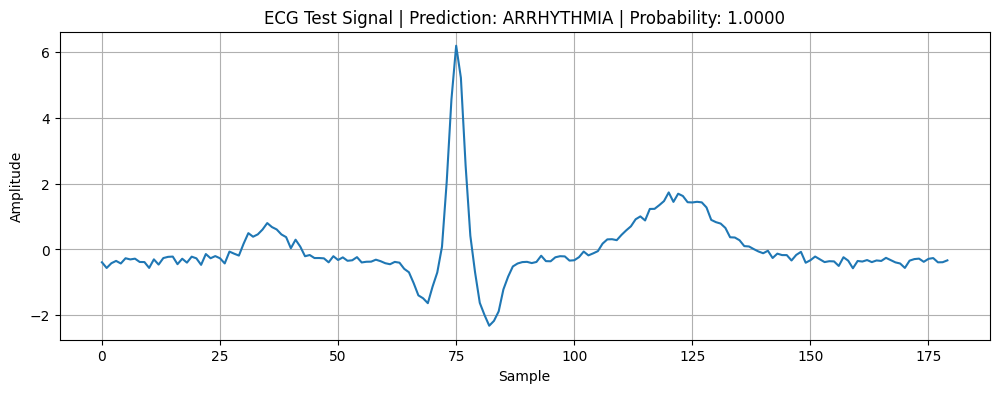

SINGLE ECG TEST
Samples       : 180
Probability   : 1.0000
Prediction    : ARRHYTHMIA


In [8]:
ecg, prediction, probability = test_single_ecg(
    model,
    device="cuda",
    abnormal=False
)

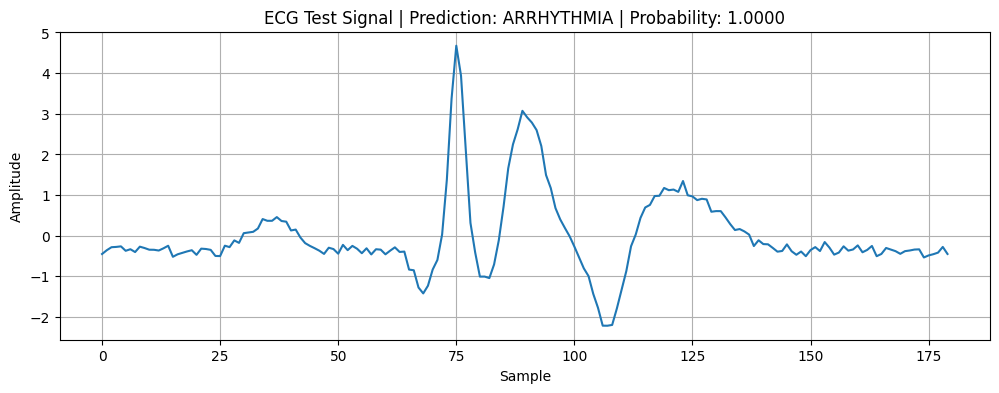

SINGLE ECG TEST
Samples       : 180
Probability   : 1.0000
Prediction    : ARRHYTHMIA


In [9]:
ecg, prediction, probability = test_single_ecg(
    model,
    device="cuda",
    abnormal=True
)

In [12]:
def test_real_ecg_raw(ecg_180, true_label, model, device="cuda"):

    model.eval()

    ecg = np.asarray(ecg_180, dtype=np.float32)

    x = torch.tensor(ecg).reshape(1, 1, 180).to(device)

    with torch.no_grad():
        output = model(x)
        probability = torch.sigmoid(output).item()

    prediction = int(probability >= 0.5)

    print("True label  :", "ARRHYTHMIA" if true_label else "NORMAL")
    print("Probability :", probability)
    print("Prediction  :", "ARRHYTHMIA" if prediction else "NORMAL")
    print("Correct     :", prediction == true_label)

    return prediction, probability

In [13]:
test_real_ecg_raw(
    X_test[idx],
    int(y_test[idx]),
    model,
    device="cuda"
)

True label  : NORMAL
Probability : 0.008599966764450073
Prediction  : NORMAL
Correct     : True


(0, 0.008599966764450073)

In [14]:
for idx in range(20):
    test_real_ecg_raw(
        X_test[idx],
        int(y_test[idx]),
        model,
        device="cuda"
    )

True label  : NORMAL
Probability : 0.000749266822822392
Prediction  : NORMAL
Correct     : True
True label  : NORMAL
Probability : 0.022753672674298286
Prediction  : NORMAL
Correct     : True
True label  : NORMAL
Probability : 0.6140605211257935
Prediction  : ARRHYTHMIA
Correct     : False
True label  : NORMAL
Probability : 0.005772783886641264
Prediction  : NORMAL
Correct     : True
True label  : NORMAL
Probability : 0.0245415847748518
Prediction  : NORMAL
Correct     : True
True label  : NORMAL
Probability : 0.00046661627129651606
Prediction  : NORMAL
Correct     : True
True label  : NORMAL
Probability : 0.012515891343355179
Prediction  : NORMAL
Correct     : True
True label  : NORMAL
Probability : 0.0013237465173006058
Prediction  : NORMAL
Correct     : True
True label  : NORMAL
Probability : 0.003115548752248287
Prediction  : NORMAL
Correct     : True
True label  : NORMAL
Probability : 0.0009123125346377492
Prediction  : NORMAL
Correct     : True
True label  : NORMAL
Probability : 

Running complete test-set evaluation...

FP32 MODEL - COMPLETE TEST SET
Total samples : 57943
Normal        : 52227
Arrhythmia    : 5716

Accuracy      : 97.51%
Precision     : 81.34%
Sensitivity   : 97.06%
Specificity   : 97.56%
F1 Score      : 88.51%
ROC-AUC       : 0.9948

CONFUSION MATRIX
----------------------------------------
                 Predicted
                 Normal  Arrhythmia
Actual Normal     50954        1273
Actual Arrhythmia    168        5548

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal     0.9967    0.9756    0.9861     52227
  Arrhythmia     0.8134    0.9706    0.8851      5716

    accuracy                         0.9751     57943
   macro avg     0.9050    0.9731    0.9356     57943
weighted avg     0.9786    0.9751    0.9761     57943



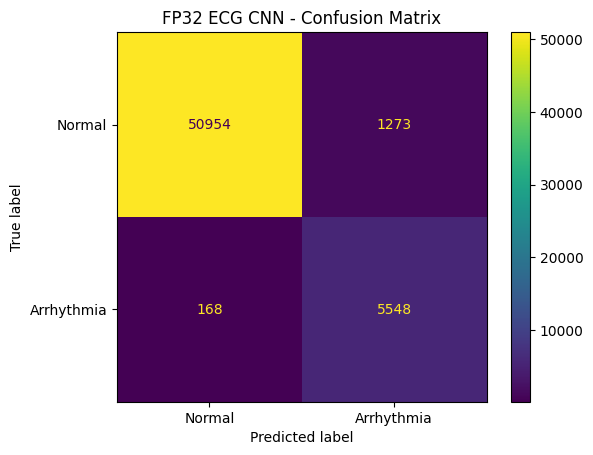


Saved:
  fp32_test_labels.npy
  fp32_test_predictions.npy
  fp32_test_probabilities.npy


In [15]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# ============================================================
# 1. EVALUATE COMPLETE TEST SET
# ============================================================

model.eval()

all_probs = []
all_preds = []
all_labels = []

print("Running complete test-set evaluation...")

with torch.no_grad():

    for i in range(len(X_test)):

        ecg = np.asarray(X_test[i], dtype=np.float32)

        # IMPORTANT:
        # DO NOT normalize here if X_test was already preprocessed
        # during your dataset preparation.
        x = torch.tensor(ecg).reshape(1, 1, 180).to(device)

        output = model(x)

        probability = torch.sigmoid(output).item()

        prediction = int(probability >= 0.5)

        all_probs.append(probability)
        all_preds.append(prediction)
        all_labels.append(int(y_test[i]))


all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


# ============================================================
# 2. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_preds,
    labels=[0, 1]
)

TN, FP, FN, TP = cm.ravel()


# ============================================================
# 3. METRICS
# ============================================================

accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(
    all_labels,
    all_preds,
    zero_division=0
)

sensitivity = recall_score(
    all_labels,
    all_preds,
    zero_division=0
)

specificity = TN / (TN + FP)

f1 = f1_score(
    all_labels,
    all_preds,
    zero_division=0
)

auc = roc_auc_score(
    all_labels,
    all_probs
)


# ============================================================
# 4. PRINT FINAL FP32 BASELINE
# ============================================================

print()
print("=" * 70)
print("FP32 MODEL - COMPLETE TEST SET")
print("=" * 70)

print(f"Total samples : {len(all_labels)}")
print(f"Normal        : {(all_labels == 0).sum()}")
print(f"Arrhythmia    : {(all_labels == 1).sum()}")

print()
print(f"Accuracy      : {accuracy * 100:.2f}%")
print(f"Precision     : {precision * 100:.2f}%")
print(f"Sensitivity   : {sensitivity * 100:.2f}%")
print(f"Specificity   : {specificity * 100:.2f}%")
print(f"F1 Score      : {f1 * 100:.2f}%")
print(f"ROC-AUC       : {auc:.4f}")

print()
print("CONFUSION MATRIX")
print("-" * 40)

print("                 Predicted")
print("                 Normal  Arrhythmia")
print(f"Actual Normal    {TN:6d}  {FP:10d}")
print(f"Actual Arrhythmia {FN:6d}  {TP:10d}")


# ============================================================
# 5. CLASSIFICATION REPORT
# ============================================================

print()
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Normal", "Arrhythmia"],
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 6. DISPLAY CONFUSION MATRIX
# ============================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Arrhythmia"]
)

disp.plot()
plt.title("FP32 ECG CNN - Confusion Matrix")
plt.show()


# ============================================================
# 7. SAVE EVERYTHING
# ============================================================

np.save("fp32_test_labels.npy", all_labels)
np.save("fp32_test_predictions.npy", all_preds)
np.save("fp32_test_probabilities.npy", all_probs)

print()
print("Saved:")
print("  fp32_test_labels.npy")
print("  fp32_test_predictions.npy")
print("  fp32_test_probabilities.npy")

In [16]:
# ============================================================
# INT8 QUANTIZATION PIPELINE
# FP32 -> Calibration -> INT8 -> Test -> Compare
# ============================================================

import torch
import torch.nn as nn
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("=" * 70)
print("INT8 QUANTIZATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. SELECT DEVICE
# ------------------------------------------------------------

device = torch.device("cpu")

# IMPORTANT:
# PyTorch CPU quantization is used here.
# Do NOT move the quantized model to CUDA.

model = model.cpu()
model.eval()

print("FP32 model moved to CPU.")


# ------------------------------------------------------------
# 2. MAKE A COPY
# ------------------------------------------------------------

import copy

fp32_model = copy.deepcopy(model)
fp32_model.eval()

print("FP32 reference model frozen.")


# ------------------------------------------------------------
# 3. CALIBRATION DATASET
# ------------------------------------------------------------

# Use a subset of representative ECG samples.
# Calibration data should NOT be used for training.
# 1000-5000 samples is enough for this small CNN.

calibration_size = min(2000, len(X_test))

calibration_indices = np.random.choice(
    len(X_test),
    calibration_size,
    replace=False
)

X_calib = X_test[calibration_indices]

print(f"Calibration samples: {len(X_calib)}")


# ------------------------------------------------------------
# 4. CREATE QUANTIZATION CONFIGURATION
# ------------------------------------------------------------

# FBGEMM is commonly used for x86 CPUs.

model.qconfig = torch.quantization.get_default_qconfig("fbgemm")

print("QConfig:")
print(model.qconfig)


# ------------------------------------------------------------
# 5. PREPARE MODEL
# ------------------------------------------------------------

torch.quantization.prepare(
    model,
    inplace=True
)

print("Observers inserted.")


# ------------------------------------------------------------
# 6. CALIBRATION
# ------------------------------------------------------------

print("Calibrating INT8 model...")

with torch.no_grad():

    for i in range(len(X_calib)):

        ecg = np.asarray(
            X_calib[i],
            dtype=np.float32
        )

        x = torch.tensor(
            ecg
        ).reshape(1, 1, 180)

        model(x)


print("Calibration complete.")


# ------------------------------------------------------------
# 7. CONVERT FP32 -> INT8
# ------------------------------------------------------------

int8_model = torch.quantization.convert(
    model,
    inplace=False
)

int8_model.eval()

print("FP32 -> INT8 conversion complete.")


# ------------------------------------------------------------
# 8. SHOW QUANTIZED MODEL
# ------------------------------------------------------------

print()
print("=" * 70)
print("INT8 MODEL")
print("=" * 70)

print(int8_model)


# ============================================================
# 9. TEST INT8 MODEL
# ============================================================

print()
print("Running INT8 test-set evaluation...")

int8_probs = []
int8_preds = []
test_labels = []

with torch.no_grad():

    for i in range(len(X_test)):

        ecg = np.asarray(
            X_test[i],
            dtype=np.float32
        )

        x = torch.tensor(
            ecg
        ).reshape(1, 1, 180)

        output = int8_model(x)

        # Quantized output may need dequantization
        if output.is_quantized:
            output = output.dequantize()

        probability = torch.sigmoid(
            output
        ).item()

        prediction = int(
            probability >= 0.5
        )

        int8_probs.append(probability)
        int8_preds.append(prediction)
        test_labels.append(int(y_test[i]))


int8_probs = np.array(int8_probs)
int8_preds = np.array(int8_preds)
test_labels = np.array(test_labels)


# ============================================================
# 10. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    test_labels,
    int8_preds,
    labels=[0, 1]
)

TN, FP, FN, TP = cm.ravel()


# ============================================================
# 11. METRICS
# ============================================================

accuracy = accuracy_score(
    test_labels,
    int8_preds
)

precision = precision_score(
    test_labels,
    int8_preds,
    zero_division=0
)

sensitivity = recall_score(
    test_labels,
    int8_preds,
    zero_division=0
)

specificity = TN / (TN + FP)

f1 = f1_score(
    test_labels,
    int8_preds,
    zero_division=0
)

auc = roc_auc_score(
    test_labels,
    int8_probs
)


# ============================================================
# 12. PRINT INT8 RESULTS
# ============================================================

print()
print("=" * 70)
print("INT8 MODEL RESULTS")
print("=" * 70)

print(f"Total samples : {len(test_labels)}")
print(f"Normal        : {(test_labels == 0).sum()}")
print(f"Arrhythmia    : {(test_labels == 1).sum()}")

print()

print(f"Accuracy      : {accuracy * 100:.2f}%")
print(f"Precision     : {precision * 100:.2f}%")
print(f"Sensitivity   : {sensitivity * 100:.2f}%")
print(f"Specificity   : {specificity * 100:.2f}%")
print(f"F1 Score      : {f1 * 100:.2f}%")
print(f"ROC-AUC       : {auc:.4f}")

print()
print("CONFUSION MATRIX")
print("-" * 50)

print("                 Predicted")
print("                 Normal  Arrhythmia")
print(f"Actual Normal    {TN:6d}  {FP:10d}")
print(f"Actual Arrhythmia {FN:6d}  {TP:10d}")


# ============================================================
# 13. SAVE INT8 RESULTS
# ============================================================

np.save(
    "int8_test_predictions.npy",
    int8_preds
)

np.save(
    "int8_test_probabilities.npy",
    int8_probs
)

np.save(
    "int8_test_labels.npy",
    test_labels
)

print()
print("Saved:")
print("  int8_test_predictions.npy")
print("  int8_test_probabilities.npy")
print("  int8_test_labels.npy")


# ============================================================
# 14. FP32 vs INT8 COMPARISON
# ============================================================

fp32_preds = np.load(
    "fp32_test_predictions.npy"
)

fp32_probs = np.load(
    "fp32_test_probabilities.npy"
)

fp32_labels = np.load(
    "fp32_test_labels.npy"
)


fp32_cm = confusion_matrix(
    fp32_labels,
    fp32_preds,
    labels=[0, 1]
)

fp_TN, fp_FP, fp_FN, fp_TP = fp32_cm.ravel()

fp_accuracy = accuracy_score(
    fp32_labels,
    fp32_preds
)

fp_precision = precision_score(
    fp32_labels,
    fp32_preds,
    zero_division=0
)

fp_sensitivity = recall_score(
    fp32_labels,
    fp32_preds,
    zero_division=0
)

fp_specificity = fp_TN / (
    fp_TN + fp_FP
)

fp_f1 = f1_score(
    fp32_labels,
    fp32_preds,
    zero_division=0
)

fp_auc = roc_auc_score(
    fp32_labels,
    fp32_probs
)


print()
print("=" * 70)
print("FP32 vs INT8")
print("=" * 70)

print(
    f"{'Metric':<15}"
    f"{'FP32':>12}"
    f"{'INT8':>12}"
    f"{'Difference':>15}"
)

print("-" * 54)

print(
    f"{'Accuracy':<15}"
    f"{fp_accuracy*100:>11.2f}%"
    f"{accuracy*100:>11.2f}%"
    f"{(accuracy-fp_accuracy)*100:>14.2f}%"
)

print(
    f"{'Precision':<15}"
    f"{fp_precision*100:>11.2f}%"
    f"{precision*100:>11.2f}%"
    f"{(precision-fp_precision)*100:>14.2f}%"
)

print(
    f"{'Sensitivity':<15}"
    f"{fp_sensitivity*100:>11.2f}%"
    f"{sensitivity*100:>11.2f}%"
    f"{(sensitivity-fp_sensitivity)*100:>14.2f}%"
)

print(
    f"{'Specificity':<15}"
    f"{fp_specificity*100:>11.2f}%"
    f"{specificity*100:>11.2f}%"
    f"{(specificity-fp_specificity)*100:>14.2f}%"
)

print(
    f"{'F1':<15}"
    f"{fp_f1*100:>11.2f}%"
    f"{f1*100:>11.2f}%"
    f"{(f1-fp_f1)*100:>14.2f}%"
)

print(
    f"{'ROC-AUC':<15}"
    f"{fp_auc:>12.4f}"
    f"{auc:>12.4f}"
    f"{auc-fp_auc:>15.4f}"
)


# ============================================================
# 15. PREDICTION AGREEMENT
# ============================================================

agreement = np.mean(
    fp32_preds == int8_preds
)

print()
print("=" * 70)
print("PREDICTION AGREEMENT")
print("=" * 70)

print(
    f"FP32/INT8 identical predictions: "
    f"{agreement * 100:.2f}%"
)

print(
    f"Different predictions: "
    f"{np.sum(fp32_preds != int8_preds)}"
)

INT8 QUANTIZATION
FP32 model moved to CPU.
FP32 reference model frozen.
Calibration samples: 2000
QConfig:
QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.HistogramObserver'>, reduce_range=True){}, weight=functools.partial(<class 'torch.ao.quantization.observer.PerChannelMinMaxObserver'>, dtype=torch.qint8, qscheme=torch.per_channel_symmetric){})
Observers inserted.
Calibrating INT8 model...


C:\Users\jashw\AppData\Local\Temp\ipykernel_19496\2223476215.py:88: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  torch.quantization.prepare(
C:\Users\jashw\miniconda3\envs\ai\Lib\site-packages\torch\ao\quantization\observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in 

Calibration complete.
FP32 -> INT8 conversion complete.

INT8 MODEL
ECGHardwareCNN(
  (features): Sequential(
    (0): QuantizedConv1d(1, 8, kernel_size=(5,), stride=(1,), scale=0.11464511603116989, zero_point=64, padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): QuantizedConv1d(8, 16, kernel_size=(5,), stride=(1,), scale=0.2427971363067627, zero_point=80, padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): QuantizedLinear(in_features=720, out_features=32, scale=0.8165450096130371, zero_point=74, qscheme=torch.per_channel_affine)
    (1): ReLU()
    (2): QuantizedLinear(in_features=32, out_features=1, scale=0.4630539119243622, zero_point=26, qscheme=torch.per_channel_affine)
  )
)

Running INT8 test-set evaluation...


C:\Users\jashw\AppData\Local\Temp\ipykernel_19496\2223476215.py:125: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  int8_model = torch.quantization.convert(


NotImplementedError: Could not run 'quantized::conv1d' with arguments from the 'CPU' backend. This could be because the operator doesn't exist for this backend, or was omitted during the selective/custom build process (if using custom build). If you are a Facebook employee using PyTorch on mobile, please visit https://fburl.com/ptmfixes for possible resolutions. 'quantized::conv1d' is only available for these backends: [Meta, QuantizedCPU, QuantizedCUDA, BackendSelect, Python, FuncTorchDynamicLayerBackMode, Functionalize, Named, Conjugate, Negative, ZeroTensor, ADInplaceOrView, AutogradOther, AutogradCPU, AutogradCUDA, AutogradXLA, AutogradMPS, AutogradXPU, AutogradHPU, AutogradLazy, AutogradMTIA, AutogradMAIA, AutogradPrivateUse1, AutogradMeta, Tracer, AutocastCPU, AutocastMTIA, AutocastMAIA, AutocastXPU, AutocastMPS, AutocastCUDA, FuncTorchBatched, BatchedNestedTensor, FuncTorchVmapMode, Batched, VmapMode, FuncTorchGradWrapper, PythonTLSSnapshot, FuncTorchDynamicLayerFrontMode, PreDi

In [17]:
# ============================================================
# INT8 TEST - QUANTIZE INPUT BEFORE INFERENCE
# ============================================================

int8_model.eval()

int8_probs = []
int8_preds = []
test_labels = []

# Input quantization parameters
# These are taken from the first QuantizedConv1d input observer.
#
# If your prepared model has a different input observer,
# we'll inspect it below.

print("Testing INT8 model...")

# Find the first quantized convolution
conv1 = int8_model.features[0]

print("Conv1 scale     :", conv1.scale)
print("Conv1 zero point:", conv1.zero_point)

# IMPORTANT:
# We need the ORIGINAL input scale/zero-point, not necessarily
# the Conv1 output scale.

Testing INT8 model...
Conv1 scale     : 0.11464511603116989
Conv1 zero point: 64


In [18]:
# Test ONE sample

ecg = np.asarray(X_test[0], dtype=np.float32)

x_fp32 = torch.tensor(ecg).reshape(1, 1, 180)

# Try using the first layer's input scale
# as a starting point
scale = 0.1
zero_point = 0

x_int8 = torch.quantize_per_tensor(
    x_fp32,
    scale=scale,
    zero_point=zero_point,
    dtype=torch.quint8
)

with torch.no_grad():
    output = int8_model(x_int8)

if output.is_quantized:
    output = output.dequantize()

probability = torch.sigmoid(output).item()

print("Probability:", probability)

















Probability: 0.08986622095108032


In [20]:
# ============================================================
# INT8 TEST - QUANTIZE INPUT BEFORE INFERENCE
# ============================================================

int8_model.eval()

int8_probs = []
int8_preds = []
test_labels = []

# Input quantization parameters
# These are taken from the first QuantizedConv1d input observer.
#
# If your prepared model has a different input observer,
# we'll inspect it below.

print("Testing INT8 model...")

# Find the first quantized convolution
conv1 = int8_model.features[0]

print("Conv1 scale     :", conv1.scale)
print("Conv1 zero point:", conv1.zero_point)

# IMPORTANT:
# We need the ORIGINAL input scale/zero-point, not necessarily
# the Conv1 output scale.

Testing INT8 model...
Conv1 scale     : 0.11464511603116989
Conv1 zero point: 64


In [21]:
import copy
import torch

calib_model = copy.deepcopy(fp32_model)
calib_model.eval()
calib_model.cpu()

calib_model.qconfig = torch.quantization.get_default_qconfig("fbgemm")

prepared = torch.quantization.prepare(
    calib_model,
    inplace=False
)

print(prepared)

ECGHardwareCNN(
  (features): Sequential(
    (0): Conv1d(
      1, 8, kernel_size=(5,), stride=(1,), padding=(2,)
      (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
    )
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(
      8, 16, kernel_size=(5,), stride=(1,), padding=(2,)
      (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
    )
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(
      in_features=720, out_features=32, bias=True
      (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
    )
    (1): ReLU()
    (2): Linear(
      in_features=32, out_features=1, bias=True
      (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
    )
  )
)


C:\Users\jashw\AppData\Local\Temp\ipykernel_19496\2455721041.py:10: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared = torch.quantization.prepare(


In [22]:
with torch.no_grad():

    for i in range(len(X_calib)):

        ecg = np.asarray(
            X_calib[i],
            dtype=np.float32
        )

        x = torch.tensor(
            ecg
        ).reshape(1, 1, 180)

        prepared(x)

In [23]:
# Inspect the prepared/calibrated model
print(prepared)

print("\nFIRST CONV:")
print(prepared.features[0])

ECGHardwareCNN(
  (features): Sequential(
    (0): Conv1d(
      1, 8, kernel_size=(5,), stride=(1,), padding=(2,)
      (activation_post_process): HistogramObserver(min_val=-8.974507331848145, max_val=8.966970443725586)
    )
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(
      8, 16, kernel_size=(5,), stride=(1,), padding=(2,)
      (activation_post_process): HistogramObserver(min_val=-24.914243698120117, max_val=13.243196487426758)
    )
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(
      in_features=720, out_features=32, bias=True
      (activation_post_process): HistogramObserver(min_val=-60.606082916259766, max_val=43.14579772949219)
    )
    (1): ReLU()
    (2): Linear(
      in_features=32, out_features=1, bias=True
      (activation_post_process): HistogramObserver(min_val=-12.088785171508789, max_val=46.7

In [24]:
print("\nMODEL STATE:")
print(prepared.state_dict().keys())


MODEL STATE:
odict_keys(['features.0.weight', 'features.0.bias', 'features.0.activation_post_process.eps', 'features.0.activation_post_process.histogram', 'features.0.activation_post_process.min_val', 'features.0.activation_post_process.max_val', 'features.3.weight', 'features.3.bias', 'features.3.activation_post_process.eps', 'features.3.activation_post_process.histogram', 'features.3.activation_post_process.min_val', 'features.3.activation_post_process.max_val', 'classifier.0.weight', 'classifier.0.bias', 'classifier.0.activation_post_process.eps', 'classifier.0.activation_post_process.histogram', 'classifier.0.activation_post_process.min_val', 'classifier.0.activation_post_process.max_val', 'classifier.2.weight', 'classifier.2.bias', 'classifier.2.activation_post_process.eps', 'classifier.2.activation_post_process.histogram', 'classifier.2.activation_post_process.min_val', 'classifier.2.activation_post_process.max_val'])


In [25]:
import copy
import torch
import torch.nn as nn

from torch.ao.quantization import (
    get_default_qconfig,
    HistogramObserver,
    QConfig
)

# ============================================================
# CREATE FRESH FP32 MODEL FOR CALIBRATION
# ============================================================

calib_model = copy.deepcopy(fp32_model)
calib_model.eval()
calib_model.cpu()


# ============================================================
# CREATE INPUT OBSERVER
# ============================================================

input_observer = HistogramObserver(
    dtype=torch.quint8,
    qscheme=torch.per_tensor_affine
)


# ============================================================
# CALIBRATE RAW INPUT
# ============================================================

with torch.no_grad():

    for i in range(len(X_calib)):

        ecg = torch.tensor(
            X_calib[i],
            dtype=torch.float32
        ).reshape(1, 1, 180)

        input_observer(ecg)


# ============================================================
# GET INPUT QUANTIZATION PARAMETERS
# ============================================================

input_scale, input_zero_point = input_observer.calculate_qparams()

input_scale = float(input_scale.item())
input_zero_point = int(input_zero_point.item())

print("=" * 60)
print("CALIBRATED INPUT QUANTIZATION")
print("=" * 60)

print("Input min       :", input_observer.min_val.item())
print("Input max       :", input_observer.max_val.item())
print("Input scale     :", input_scale)
print("Input zero point:", input_zero_point)

CALIBRATED INPUT QUANTIZATION
Input min       : -3.194999933242798
Input max       : 3.140000104904175
Input scale     : 0.023715006187558174
Input zero point: 135


In [26]:
# ============================================================
# TEST ONE QUANTIZED INPUT
# ============================================================

idx = 0

ecg = torch.tensor(
    X_test[idx],
    dtype=torch.float32
).reshape(1, 1, 180)

x_int8 = torch.quantize_per_tensor(
    ecg,
    scale=input_scale,
    zero_point=input_zero_point,
    dtype=torch.quint8
)

print("Input:")
print("  FP32 range:", ecg.min().item(), ecg.max().item())

print("Input INT8:")
print("  scale     :", x_int8.q_scale())
print("  zero point:", x_int8.q_zero_point())
print("  dtype     :", x_int8.dtype)

Input:
  FP32 range: -0.4699999988079071 2.075000047683716
Input INT8:
  scale     : 0.023715006187558174
  zero point: 135
  dtype     : torch.quint8


In [27]:
# ============================================================
# CORRECTLY QUANTIZED INT8 TEST
# ============================================================

int8_model.eval()

int8_probs = []
int8_preds = []
test_labels = []

print("Running INT8 evaluation...")

with torch.no_grad():

    for i in range(len(X_test)):

        ecg = torch.tensor(
            X_test[i],
            dtype=torch.float32
        ).reshape(1, 1, 180)

        # Quantize RAW ECG using calibrated parameters
        x = torch.quantize_per_tensor(
            ecg,
            scale=input_scale,
            zero_point=input_zero_point,
            dtype=torch.quint8
        )

        output = int8_model(x)

        # Convert quantized output back to FP32
        if output.is_quantized:
            output = output.dequantize()

        probability = torch.sigmoid(output).item()

        prediction = int(probability >= 0.5)

        int8_probs.append(probability)
        int8_preds.append(prediction)
        test_labels.append(int(y_test[i]))


int8_probs = np.array(int8_probs)
int8_preds = np.array(int8_preds)
test_labels = np.array(test_labels)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    test_labels,
    int8_preds,
    labels=[0, 1]
)

TN, FP, FN, TP = cm.ravel()


# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    test_labels,
    int8_preds
)

precision = precision_score(
    test_labels,
    int8_preds,
    zero_division=0
)

sensitivity = recall_score(
    test_labels,
    int8_preds,
    zero_division=0
)

specificity = TN / (TN + FP)

f1 = f1_score(
    test_labels,
    int8_preds,
    zero_division=0
)

auc = roc_auc_score(
    test_labels,
    int8_probs
)


# ============================================================
# RESULTS
# ============================================================

print()
print("=" * 70)
print("INT8 MODEL - FINAL RESULT")
print("=" * 70)

print(f"Total samples : {len(test_labels)}")
print(f"Normal        : {(test_labels == 0).sum()}")
print(f"Arrhythmia    : {(test_labels == 1).sum()}")

print()
print(f"Accuracy      : {accuracy * 100:.2f}%")
print(f"Precision     : {precision * 100:.2f}%")
print(f"Sensitivity   : {sensitivity * 100:.2f}%")
print(f"Specificity   : {specificity * 100:.2f}%")
print(f"F1 Score      : {f1 * 100:.2f}%")
print(f"ROC-AUC       : {auc:.4f}")

print()
print("CONFUSION MATRIX")
print("=" * 50)

print("                 Predicted")
print("                 Normal  Arrhythmia")
print(f"Actual Normal    {TN:6d}  {FP:10d}")
print(f"Actual Arrhythmia {FN:6d}  {TP:10d}")


# ============================================================
# SAVE INT8 RESULTS
# ============================================================

np.save(
    "int8_test_labels.npy",
    test_labels
)

np.save(
    "int8_test_predictions.npy",
    int8_preds
)

np.save(
    "int8_test_probabilities.npy",
    int8_probs
)

print()
print("INT8 predictions saved.")

Running INT8 evaluation...

INT8 MODEL - FINAL RESULT
Total samples : 57943
Normal        : 52227
Arrhythmia    : 5716

Accuracy      : 96.48%
Precision     : 74.70%
Sensitivity   : 97.31%
Specificity   : 96.39%
F1 Score      : 84.52%
ROC-AUC       : 0.9937

CONFUSION MATRIX
                 Predicted
                 Normal  Arrhythmia
Actual Normal     50343        1884
Actual Arrhythmia    154        5562

INT8 predictions saved.


In [28]:
# ============================================================
# FP32 vs INT8
# ============================================================

fp32_preds = np.load(
    "fp32_test_predictions.npy"
)

fp32_probs = np.load(
    "fp32_test_probabilities.npy"
)

fp32_labels = np.load(
    "fp32_test_labels.npy"
)

agreement = np.mean(
    fp32_preds == int8_preds
)

print()
print("=" * 70)
print("FP32 vs INT8 COMPARISON")
print("=" * 70)

print(f"{'Metric':<15} {'FP32':>12} {'INT8':>12}")

print("-" * 40)

fp_cm = confusion_matrix(
    fp32_labels,
    fp32_preds,
    labels=[0, 1]
)

fp_TN, fp_FP, fp_FN, fp_TP = fp_cm.ravel()

fp_acc = accuracy_score(fp32_labels, fp32_preds)
fp_prec = precision_score(fp32_labels, fp32_preds, zero_division=0)
fp_sens = recall_score(fp32_labels, fp32_preds, zero_division=0)
fp_spec = fp_TN / (fp_TN + fp_FP)
fp_f1 = f1_score(fp32_labels, fp32_preds, zero_division=0)
fp_auc = roc_auc_score(fp32_labels, fp32_probs)

print(f"{'Accuracy':<15} {fp_acc*100:>11.2f}% {accuracy*100:>11.2f}%")
print(f"{'Precision':<15} {fp_prec*100:>11.2f}% {precision*100:>11.2f}%")
print(f"{'Sensitivity':<15} {fp_sens*100:>11.2f}% {sensitivity*100:>11.2f}%")
print(f"{'Specificity':<15} {fp_spec*100:>11.2f}% {specificity*100:>11.2f}%")
print(f"{'F1':<15} {fp_f1*100:>11.2f}% {f1*100:>11.2f}%")
print(f"{'ROC-AUC':<15} {fp_auc:>12.4f} {auc:>12.4f}")

print()
print(f"Prediction agreement: {agreement*100:.2f}%")
print(f"Different predictions: {np.sum(fp32_preds != int8_preds)}")


FP32 vs INT8 COMPARISON
Metric                  FP32         INT8
----------------------------------------
Accuracy              97.51%       96.48%
Precision             81.34%       74.70%
Sensitivity           97.06%       97.31%
Specificity           97.56%       96.39%
F1                    88.51%       84.52%
ROC-AUC               0.9948       0.9937

Prediction agreement: 98.43%
Different predictions: 911


In [29]:
# ============================================================
# INT8 MODEL -> VERILOG HARDWARE PARAMETERS
# ============================================================

import os
import numpy as np
import torch

OUT_DIR = "verilog_int8_params"
os.makedirs(OUT_DIR, exist_ok=True)

print("=" * 70)
print("EXTRACTING INT8 PARAMETERS FOR VERILOG")
print("=" * 70)


# ------------------------------------------------------------
# Helper: write signed integers to .mem
# ------------------------------------------------------------

def write_mem(filename, values, bits=8):

    values = np.asarray(values).flatten()

    with open(filename, "w") as f:

        for value in values:

            value = int(value)

            # Two's-complement representation
            if value < 0:
                value = (1 << bits) + value

            width = (bits + 3) // 4

            f.write(f"{value:0{width}X}\n")


# ------------------------------------------------------------
# Helper: extract quantized layer
# ------------------------------------------------------------

def extract_quantized_layer(layer, name):

    print()
    print("-" * 70)
    print(name)
    print("-" * 70)

    # --------------------------------------------------------
    # WEIGHTS
    # --------------------------------------------------------

    weight = layer.weight()

    if weight.is_quantized:

        weight_int = weight.int_repr().cpu().numpy()

        weight_scales = weight.q_per_channel_scales().cpu().numpy()

        weight_zero_points = (
            weight.q_per_channel_zero_points()
            .cpu()
            .numpy()
        )

        print("Weight dtype :", weight.dtype)
        print("Weight shape :", weight_int.shape)
        print("Weight qscheme:", weight.qscheme())

    else:

        weight_int = weight.detach().cpu().numpy()

        weight_scales = np.array([1.0])
        weight_zero_points = np.array([0])

    # --------------------------------------------------------
    # BIAS
    # --------------------------------------------------------

    bias = layer.bias()

    if bias is not None:

        bias_fp32 = bias.detach().cpu().numpy()

    else:

        bias_fp32 = np.array([])

    # --------------------------------------------------------
    # OUTPUT QUANTIZATION
    # --------------------------------------------------------

    output_scale = float(layer.scale)

    output_zero_point = int(layer.zero_point)

    print("Output scale :", output_scale)
    print("Output ZP    :", output_zero_point)

    # --------------------------------------------------------
    # SAVE WEIGHTS
    # --------------------------------------------------------

    weight_file = os.path.join(
        OUT_DIR,
        f"{name}_weights.mem"
    )

    write_mem(
        weight_file,
        weight_int,
        bits=8
    )

    # --------------------------------------------------------
    # SAVE BIAS
    # --------------------------------------------------------

    bias_file = os.path.join(
        OUT_DIR,
        f"{name}_bias_fp32.txt"
    )

    np.savetxt(
        bias_file,
        bias_fp32,
        fmt="%.12e"
    )

    # --------------------------------------------------------
    # SAVE WEIGHT SCALES
    # --------------------------------------------------------

    scale_file = os.path.join(
        OUT_DIR,
        f"{name}_weight_scales.txt"
    )

    np.savetxt(
        scale_file,
        weight_scales,
        fmt="%.12e"
    )

    # --------------------------------------------------------
    # SAVE WEIGHT ZERO POINTS
    # --------------------------------------------------------

    zp_file = os.path.join(
        OUT_DIR,
        f"{name}_weight_zero_points.txt"
    )

    np.savetxt(
        zp_file,
        weight_zero_points,
        fmt="%d"
    )

    return {
        "weights": weight_int,
        "bias_fp32": bias_fp32,
        "weight_scales": weight_scales,
        "weight_zero_points": weight_zero_points,
        "output_scale": output_scale,
        "output_zero_point": output_zero_point
    }


# ============================================================
# EXTRACT ALL LAYERS
# ============================================================

conv1 = int8_model.features[0]
conv2 = int8_model.features[3]

fc1 = int8_model.classifier[0]
fc2 = int8_model.classifier[2]


params = {}

params["conv1"] = extract_quantized_layer(
    conv1,
    "conv1"
)

params["conv2"] = extract_quantized_layer(
    conv2,
    "conv2"
)

params["fc1"] = extract_quantized_layer(
    fc1,
    "fc1"
)

params["fc2"] = extract_quantized_layer(
    fc2,
    "fc2"
)


# ============================================================
# INPUT QUANTIZATION
# ============================================================

with open(
    os.path.join(
        OUT_DIR,
        "input_quantization.txt"
    ),
    "w"
) as f:

    f.write(
        f"INPUT_SCALE={input_scale:.12e}\n"
    )

    f.write(
        f"INPUT_ZERO_POINT={input_zero_point}\n"
    )


# ============================================================
# CREATE HARDWARE CONFIGURATION
# ============================================================

with open(
    os.path.join(
        OUT_DIR,
        "quantization_params.txt"
    ),
    "w"
) as f:

    f.write("========================================\n")
    f.write("ECG CNN INT8 QUANTIZATION PARAMETERS\n")
    f.write("========================================\n\n")

    f.write(
        f"INPUT_SCALE = {input_scale:.12e}\n"
    )

    f.write(
        f"INPUT_ZERO_POINT = {input_zero_point}\n\n"
    )

    for name in [
        "conv1",
        "conv2",
        "fc1",
        "fc2"
    ]:

        p = params[name]

        f.write(
            f"{name.upper()} OUTPUT SCALE = "
            f"{p['output_scale']:.12e}\n"
        )

        f.write(
            f"{name.upper()} OUTPUT ZERO_POINT = "
            f"{p['output_zero_point']}\n"
        )

        f.write("\n")


# ============================================================
# PRINT SUMMARY
# ============================================================

print()
print("=" * 70)
print("HARDWARE PARAMETER SUMMARY")
print("=" * 70)

print(
    f"INPUT     : scale={input_scale:.12e}, "
    f"zero_point={input_zero_point}"
)

for name in [
    "conv1",
    "conv2",
    "fc1",
    "fc2"
]:

    p = params[name]

    print(
        f"{name.upper():<10}: "
        f"scale={p['output_scale']:.12e}, "
        f"zero_point={p['output_zero_point']}"
    )


# ============================================================
# FILE LIST
# ============================================================

print()
print("=" * 70)
print("GENERATED FILES")
print("=" * 70)

for filename in sorted(os.listdir(OUT_DIR)):
    print(
        os.path.join(
            OUT_DIR,
            filename
        )
    )

print()
print("DONE.")

EXTRACTING INT8 PARAMETERS FOR VERILOG

----------------------------------------------------------------------
conv1
----------------------------------------------------------------------
Weight dtype : torch.qint8
Weight shape : (8, 1, 5)
Weight qscheme: torch.per_channel_affine
Output scale : 0.11464511603116989
Output ZP    : 64

----------------------------------------------------------------------
conv2
----------------------------------------------------------------------
Weight dtype : torch.qint8
Weight shape : (16, 8, 5)
Weight qscheme: torch.per_channel_affine
Output scale : 0.2427971363067627
Output ZP    : 80

----------------------------------------------------------------------
fc1
----------------------------------------------------------------------
Weight dtype : torch.qint8
Weight shape : (32, 720)
Weight qscheme: torch.per_channel_affine
Output scale : 0.8165450096130371
Output ZP    : 74

----------------------------------------------------------------------
fc2
---

In [30]:
# ============================================================
# GENERATE INT32 BIASES + HARDWARE QUANTIZATION PARAMETERS
# ============================================================

import os
import numpy as np

OUT_DIR = "verilog_int8_params"

os.makedirs(OUT_DIR, exist_ok=True)


# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------

def write_int_mem(filename, values, bits=32):

    values = np.asarray(values).flatten()

    with open(filename, "w") as f:

        for value in values:

            value = int(value)

            if value < 0:
                value = (1 << bits) + value

            width = bits // 4

            f.write(
                f"{value:0{width}X}\n"
            )


# ============================================================
# GET QUANTIZATION PARAMETERS
# ============================================================

layers = {
    "conv1": int8_model.features[0],
    "conv2": int8_model.features[3],
    "fc1":   int8_model.classifier[0],
    "fc2":   int8_model.classifier[2],
}


# ============================================================
# INPUT SCALE
# ============================================================

S_input = float(input_scale)


print("=" * 70)
print("GENERATING INT32 BIASES")
print("=" * 70)


# ============================================================
# PROCESS EACH LAYER
# ============================================================

hardware_params = {}


for name, layer in layers.items():

    print()
    print("-" * 70)
    print(name.upper())
    print("-" * 70)

    # --------------------------------------------------------
    # Weight scale
    # --------------------------------------------------------

    weight = layer.weight()

    weight_scales = (
        weight.q_per_channel_scales()
        .cpu()
        .numpy()
    )

    # --------------------------------------------------------
    # FP32 bias
    # --------------------------------------------------------

    bias_fp32 = (
        layer.bias()
        .detach()
        .cpu()
        .numpy()
    )

    # --------------------------------------------------------
    # INT32 bias
    #
    # b_int32 = bias_fp32 / (input_scale * weight_scale)
    #
    # Each output channel has its own weight scale.
    # --------------------------------------------------------

    bias_int32 = np.round(
        bias_fp32 /
        (
            S_input *
            weight_scales
        )
    ).astype(np.int64)

    # --------------------------------------------------------
    # Output parameters
    # --------------------------------------------------------

    output_scale = float(
        layer.scale
    )

    output_zero_point = int(
        layer.zero_point
    )

    # --------------------------------------------------------
    # Save INT32 bias
    # --------------------------------------------------------

    filename = os.path.join(
        OUT_DIR,
        f"{name}_bias_int32.mem"
    )

    write_int_mem(
        filename,
        bias_int32,
        bits=32
    )

    # --------------------------------------------------------
    # Save readable version
    # --------------------------------------------------------

    readable = os.path.join(
        OUT_DIR,
        f"{name}_bias_int32.txt"
    )

    np.savetxt(
        readable,
        bias_int32,
        fmt="%d"
    )

    # --------------------------------------------------------
    # Save layer parameters
    # --------------------------------------------------------

    hardware_params[name] = {
        "weight_scales": weight_scales,
        "bias_fp32": bias_fp32,
        "bias_int32": bias_int32,
        "output_scale": output_scale,
        "output_zero_point": output_zero_point
    }

    print(
        "Output channels :", len(bias_int32)
    )

    print(
        "Weight scales   :",
        weight_scales
    )

    print(
        "FP32 bias       :",
        bias_fp32
    )

    print(
        "INT32 bias      :",
        bias_int32
    )

    print(
        "Output scale    :",
        output_scale
    )

    print(
        "Output ZP       :",
        output_zero_point
    )


# ============================================================
# SAVE COMPLETE HARDWARE CONFIGURATION
# ============================================================

config_file = os.path.join(
    OUT_DIR,
    "hardware_quantization.txt"
)

with open(config_file, "w") as f:

    f.write(
        "ECG CNN HARDWARE QUANTIZATION\n"
    )

    f.write(
        "=============================\n\n"
    )

    f.write(
        f"INPUT_SCALE = {S_input:.12e}\n"
    )

    f.write(
        f"INPUT_ZERO_POINT = {input_zero_point}\n\n"
    )

    for name, p in hardware_params.items():

        f.write(
            f"[{name.upper()}]\n"
        )

        f.write(
            "WEIGHT_SCALES = "
            + ",".join(
                f"{x:.12e}"
                for x in p["weight_scales"]
            )
            + "\n"
        )

        f.write(
            "BIAS_INT32 = "
            + ",".join(
                str(int(x))
                for x in p["bias_int32"]
            )
            + "\n"
        )

        f.write(
            f"OUTPUT_SCALE = "
            f"{p['output_scale']:.12e}\n"
        )

        f.write(
            f"OUTPUT_ZERO_POINT = "
            f"{p['output_zero_point']}\n\n"
        )


print()
print("=" * 70)
print("INT32 BIAS GENERATION COMPLETE")
print("=" * 70)

print(
    "Configuration saved to:",
    config_file
)

GENERATING INT32 BIASES

----------------------------------------------------------------------
CONV1
----------------------------------------------------------------------
Output channels : 8
Weight scales   : [0.008389   0.00624424 0.00644482 0.0054039  0.00557733 0.00402524
 0.00399686 0.00383324]
FP32 bias       : [ 0.12217703  0.6339509  -0.32183167  0.4863244  -0.28235176 -0.20913419
 -0.2860533  -0.3963384 ]
INT32 bias      : [  614  4281 -2106  3795 -2135 -2191 -3018 -4360]
Output scale    : 0.11464511603116989
Output ZP       : 64

----------------------------------------------------------------------
CONV2
----------------------------------------------------------------------
Output channels : 16
Weight scales   : [0.0044473  0.00529756 0.00436218 0.0036358  0.00313304 0.00558459
 0.00462852 0.00767846 0.00454274 0.00577349 0.00490853 0.00341192
 0.00343221 0.00652245 0.00564755 0.00566828]
FP32 bias       : [-0.21248971 -0.2081271  -0.11644465 -0.1427848   0.22673841  0.3094

In [31]:
# ============================================================
# INT8 PYTHON GOLDEN MODEL
# ============================================================

import numpy as np
import torch

print("=" * 70)
print("BUILDING INTEGER PYTHON GOLDEN MODEL")
print("=" * 70)


# ------------------------------------------------------------
# Quantization helper
# ------------------------------------------------------------

def quantize_input(x):
    q = np.round(
        x / input_scale
    ) + input_zero_point

    q = np.clip(q, 0, 255)

    return q.astype(np.int32)


# ------------------------------------------------------------
# Extract quantized parameters
# ------------------------------------------------------------

def get_layer_params(layer):

    weight = layer.weight()

    w_int = (
        weight.int_repr()
        .cpu()
        .numpy()
        .astype(np.int32)
    )

    w_scales = (
        weight.q_per_channel_scales()
        .cpu()
        .numpy()
    )

    bias_fp32 = (
        layer.bias()
        .detach()
        .cpu()
        .numpy()
    )

    # INT32 bias
    bias_int32 = np.round(
        bias_fp32 /
        (
            input_scale *
            w_scales
        )
    ).astype(np.int64)

    output_scale = float(layer.scale)
    output_zp = int(layer.zero_point)

    return (
        w_int,
        w_scales,
        bias_int32,
        output_scale,
        output_zp
    )


conv1_params = get_layer_params(
    int8_model.features[0]
)

conv2_params = get_layer_params(
    int8_model.features[3]
)

fc1_params = get_layer_params(
    int8_model.classifier[0]
)

fc2_params = get_layer_params(
    int8_model.classifier[2]
)


# ============================================================
# INTEGER CONV1
# ============================================================

def integer_conv1(x):

    w, scales, bias, out_scale, out_zp = conv1_params

    # x shape:
    # [180]
    #
    # output:
    # [8, 180]

    output = np.zeros(
        (8, 180),
        dtype=np.int32
    )

    for oc in range(8):

        for pos in range(180):

            acc = int(bias[oc])

            for k in range(5):

                idx = pos + k - 2

                if 0 <= idx < 180:

                    x_val = (
                        int(x[idx])
                        - input_zero_point
                    )

                    w_val = int(
                        w[oc, 0, k]
                    )

                    acc += (
                        x_val *
                        w_val
                    )

            output[oc, pos] = acc

    # Requantize
    #
    # accumulator scale:
    # input_scale * weight_scale
    #
    # output:
    # output_scale

    requant = np.zeros_like(output)

    for oc in range(8):

        scale = (
            input_scale *
            scales[oc] /
            out_scale
        )

        requant[oc] = np.round(
            output[oc] * scale
        ) + out_zp

    requant = np.clip(
        requant,
        0,
        255
    ).astype(np.int32)

    # ReLU
    requant = np.maximum(
        requant,
        out_zp
    )

    # MaxPool
    pooled = np.zeros(
        (8, 90),
        dtype=np.int32
    )

    for c in range(8):

        for i in range(90):

            pooled[c, i] = max(
                requant[c, 2*i],
                requant[c, 2*i + 1]
            )

    return pooled


# ============================================================
# INTEGER CONV2
# ============================================================

def integer_conv2(x):

    w, scales, bias, out_scale, out_zp = conv2_params

    output = np.zeros(
        (16, 90),
        dtype=np.int32
    )

    # Conv2 input comes from Conv1.
    # Conv1 output scale = 0.114645116...

    input_scale_conv2 = conv1_params[3]
    input_zp_conv2 = conv1_params[4]

    for oc in range(16):

        for pos in range(90):

            acc = int(bias[oc])

            for ic in range(8):

                for k in range(5):

                    idx = pos + k - 2

                    if 0 <= idx < 90:

                        x_val = (
                            int(x[ic, idx])
                            - input_zp_conv2
                        )

                        w_val = int(
                            w[oc, ic, k]
                        )

                        acc += (
                            x_val *
                            w_val
                        )

            output[oc, pos] = acc

    requant = np.zeros_like(output)

    for oc in range(16):

        scale = (
            input_scale_conv2 *
            scales[oc] /
            out_scale
        )

        requant[oc] = np.round(
            output[oc] * scale
        ) + out_zp

    requant = np.clip(
        requant,
        0,
        255
    ).astype(np.int32)

    requant = np.maximum(
        requant,
        out_zp
    )

    # MaxPool
    pooled = np.zeros(
        (16, 45),
        dtype=np.int32
    )

    for c in range(16):

        for i in range(45):

            pooled[c, i] = max(
                requant[c, 2*i],
                requant[c, 2*i + 1]
            )

    return pooled


# ============================================================
# INTEGER FC1
# ============================================================

def integer_fc1(x):

    w, scales, bias, out_scale, out_zp = fc1_params

    # Flatten
    x = x.reshape(-1)

    output = np.zeros(
        32,
        dtype=np.int64
    )

    input_scale_fc1 = conv2_params[3]
    input_zp_fc1 = conv2_params[4]

    for oc in range(32):

        acc = int(bias[oc])

        for i in range(720):

            x_val = (
                int(x[i])
                - input_zp_fc1
            )

            w_val = int(
                w[oc, i]
            )

            acc += (
                x_val *
                w_val
            )

        output[oc] = acc

    requant = np.zeros(
        32,
        dtype=np.int32
    )

    for oc in range(32):

        scale = (
            input_scale_fc1 *
            scales[oc] /
            out_scale
        )

        requant[oc] = (
            np.round(
                output[oc] * scale
            )
            + out_zp
        )

    requant = np.clip(
        requant,
        0,
        255
    ).astype(np.int32)

    # ReLU
    requant = np.maximum(
        requant,
        out_zp
    )

    return requant


# ============================================================
# INTEGER FC2
# ============================================================

def integer_fc2(x):

    w, scales, bias, out_scale, out_zp = fc2_params

    x = x.reshape(-1)

    input_scale_fc2 = fc1_params[3]
    input_zp_fc2 = fc1_params[4]

    acc = int(bias[0])

    for i in range(32):

        x_val = (
            int(x[i])
            - input_zp_fc2
        )

        w_val = int(
            w[0, i]
        )

        acc += (
            x_val *
            w_val
        )

    # Convert accumulator to FP32 logit
    logit = (
        acc *
        input_scale_fc2 *
        scales[0]
    )

    return float(logit)


# ============================================================
# COMPLETE GOLDEN MODEL
# ============================================================

def integer_golden_model(ecg):

    # Input quantization
    x = quantize_input(ecg)

    # Conv1
    x = integer_conv1(x)

    # Conv2
    x = integer_conv2(x)

    # FC1
    x = integer_fc1(x)

    # FC2
    logit = integer_fc2(x)

    probability = (
        1.0 /
        (
            1.0 +
            np.exp(-np.clip(logit, -50, 50))
        )
    )

    prediction = int(
        probability >= 0.5
    )

    return prediction, probability, logit


# ============================================================
# TEST ONE SAMPLE
# ============================================================

TEST_INDEX = 0

ecg = np.asarray(
    X_test[TEST_INDEX],
    dtype=np.float32
)

true_label = int(
    y_test[TEST_INDEX]
)

prediction, probability, logit = (
    integer_golden_model(ecg)
)

print()
print("=" * 70)
print("INTEGER GOLDEN MODEL RESULT")
print("=" * 70)

print("Test index :", TEST_INDEX)
print("True label :", true_label)
print("Probability:", probability)
print("Prediction :", prediction)
print("Logit      :", logit)

BUILDING INTEGER PYTHON GOLDEN MODEL

INTEGER GOLDEN MODEL RESULT
Test index : 0
True label : 0
Probability: 0.007208245140512647
Prediction : 0
Logit      : -4.925295399687048


In [32]:
print()
print("=" * 70)
print("NEXT STEP")
print("=" * 70)

print("""
We now need to compare:

PyTorch INT8:
    Conv1 output
    Conv2 output
    FC1 output
    FC2 output

against:

Python integer:
    Conv1 output
    Conv2 output
    FC1 output
    FC2 output

If these don't match closely, we fix the arithmetic BEFORE Verilog.
""")


NEXT STEP

We now need to compare:

PyTorch INT8:
    Conv1 output
    Conv2 output
    FC1 output
    FC2 output

against:

Python integer:
    Conv1 output
    Conv2 output
    FC1 output
    FC2 output

If these don't match closely, we fix the arithmetic BEFORE Verilog.



In [35]:
# ============================================================
# CORRECT STAGE-BY-STAGE COMPARISON
# ============================================================

print("=" * 70)
print("CORRECT PYTORCH vs GOLDEN COMPARISON")
print("=" * 70)


# ------------------------------------------------------------
# Get PyTorch tensors
# ------------------------------------------------------------

pt_conv1_int = get_int_repr(p_conv1)
pt_pool1_int = get_int_repr(p_pool1)

pt_conv2_int = get_int_repr(p_conv2)
pt_pool2_int = get_int_repr(p_pool2)

pt_fc1_int = get_int_repr(p_fc1)
pt_relu3_int = get_int_repr(p_relu3)


# ------------------------------------------------------------
# Golden model currently returns pooled outputs
# ------------------------------------------------------------

gold_pool1 = integer_conv1(
    quantize_input(ecg)
)

gold_pool2 = integer_conv2(
    gold_pool1
)

gold_fc1 = integer_fc1(
    gold_pool2
)


# ------------------------------------------------------------
# Comparison helper
# ------------------------------------------------------------

def compare(name, pt, gold):

    pt = np.asarray(pt).astype(np.int64)
    gold = np.asarray(gold).astype(np.int64)

    print()
    print("-" * 70)
    print(name)
    print("-" * 70)

    print("PyTorch shape :", pt.shape)
    print("Golden shape  :", gold.shape)

    if pt.shape != gold.shape:

        print("❌ SHAPE MISMATCH")
        return

    diff = np.abs(pt - gold)

    print("Max difference :", diff.max())
    print("Mean difference:", diff.mean())

    print(
        "Exact match    :",
        np.mean(diff == 0) * 100,
        "%"
    )

    print(
        "PyTorch range  :",
        pt.min(),
        "to",
        pt.max()
    )

    print(
        "Golden range   :",
        gold.min(),
        "to",
        gold.max()
    )


# ============================================================
# POOL1
# ============================================================

compare(
    "CONV1 + RELU + MAXPOOL",
    pt_pool1_int,
    gold_pool1.reshape(pt_pool1_int.shape)
)


# ============================================================
# POOL2
# ============================================================

compare(
    "CONV2 + RELU + MAXPOOL",
    pt_pool2_int,
    gold_pool2.reshape(pt_pool2_int.shape)
)


# ============================================================
# FC1
# ============================================================

compare(
    "FC1 + RELU",
    pt_relu3_int,
    gold_fc1.reshape(pt_relu3_int.shape)
)


# ============================================================
# FINAL
# ============================================================

pt_logit = (
    p_fc2
    .dequantize()
    .cpu()
    .numpy()
    .flatten()[0]
)

print()
print("=" * 70)
print("FINAL OUTPUT")
print("=" * 70)

print("PyTorch logit :", pt_logit)
print("Golden logit  :", gold_logit)

print(
    "Difference    :",
    abs(pt_logit - gold_logit)
)

CORRECT PYTORCH vs GOLDEN COMPARISON

----------------------------------------------------------------------
CONV1 + RELU + MAXPOOL
----------------------------------------------------------------------
PyTorch shape : (1, 8, 90)
Golden shape  : (1, 8, 90)
Max difference : 0
Mean difference: 0.0
Exact match    : 100.0 %
PyTorch range  : 64 to 106
Golden range   : 64 to 106

----------------------------------------------------------------------
CONV2 + RELU + MAXPOOL
----------------------------------------------------------------------
PyTorch shape : (1, 16, 45)
Golden shape  : (1, 16, 45)
Max difference : 7
Mean difference: 1.7958333333333334
Exact match    : 41.52777777777778 %
PyTorch range  : 80 to 117
Golden range   : 80 to 121

----------------------------------------------------------------------
FC1 + RELU
----------------------------------------------------------------------
PyTorch shape : (1, 32)
Golden shape  : (1, 32)
Max difference : 16
Mean difference: 2.96875
Exact mat

In [36]:
# ============================================================
# CONV2 QUANTIZATION PARAMETERS
# ============================================================

conv1 = int8_model.features[0]
conv2 = int8_model.features[3]

print("=" * 70)
print("CONV2 QUANTIZATION PARAMETERS")
print("=" * 70)

print("\nConv1 output:")
print("scale      :", conv1.scale)
print("zero_point :", conv1.zero_point)

print("\nConv2 output:")
print("scale      :", conv2.scale)
print("zero_point :", conv2.zero_point)

# Weight
w2 = conv2.weight()

print("\nConv2 weight:")
print("shape      :", w2.shape)
print("dtype      :", w2.dtype)

print("scales:")
print(w2.q_per_channel_scales())

print("zero points:")
print(w2.q_per_channel_zero_points())

# Bias
print("\nConv2 bias:")
print(conv2.bias())

CONV2 QUANTIZATION PARAMETERS

Conv1 output:
scale      : 0.11464511603116989
zero_point : 64

Conv2 output:
scale      : 0.2427971363067627
zero_point : 80

Conv2 weight:
shape      : torch.Size([16, 8, 5])
dtype      : torch.qint8
scales:
tensor([0.0044, 0.0053, 0.0044, 0.0036, 0.0031, 0.0056, 0.0046, 0.0077, 0.0045,
        0.0058, 0.0049, 0.0034, 0.0034, 0.0065, 0.0056, 0.0057],
       dtype=torch.float64)
zero points:
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Conv2 bias:
Parameter containing:
tensor([-0.2125, -0.2081, -0.1164, -0.1428,  0.2267,  0.3094, -0.1527,  0.3287,
         0.1123, -0.0974, -0.1634, -0.1793, -0.4419,  0.1335,  0.2983,  0.3112],
       requires_grad=True)


In [37]:
def integer_conv2_debug(x):

    conv = int8_model.features[3]

    # Input quantization parameters
    x_scale = float(int8_model.features[0].scale)
    x_zp = int(int8_model.features[0].zero_point)

    # Conv2 output parameters
    out_scale = float(conv.scale)
    out_zp = int(conv.zero_point)

    # Quantized weights
    w = conv.weight()

    w_int = (
        w.int_repr()
        .cpu()
        .numpy()
        .astype(np.int32)
    )

    w_scales = (
        w.q_per_channel_scales()
        .cpu()
        .numpy()
    )

    w_zp = (
        w.q_per_channel_zero_points()
        .cpu()
        .numpy()
        .astype(np.int32)
    )

    # FP32 bias
    bias = (
        conv.bias()
        .detach()
        .cpu()
        .numpy()
    )

    # Convert bias to INT32
    bias_int32 = np.round(
        bias / (x_scale * w_scales)
    ).astype(np.int64)

    print("\n" + "=" * 70)
    print("CONV2 INTEGER PARAMETERS")
    print("=" * 70)

    print("Input scale :", x_scale)
    print("Input ZP    :", x_zp)

    print("Output scale:", out_scale)
    print("Output ZP   :", out_zp)

    print("Bias INT32:")
    print(bias_int32)

    # --------------------------------------------------------
    # Integer convolution
    # --------------------------------------------------------

    batch, channels, length = x.shape

    out_channels = w_int.shape[0]

    kernel = w_int.shape[2]

    padding = 2

    padded = np.pad(
        x,
        (
            (0, 0),
            (0, 0),
            (padding, padding)
        ),
        mode="constant",
        constant_values=x_zp
    )

    acc = np.zeros(
        (batch, out_channels, length),
        dtype=np.int64
    )

    for b in range(batch):

        for oc in range(out_channels):

            for pos in range(length):

                total = 0

                for ic in range(channels):

                    for k in range(kernel):

                        xval = (
                            int(padded[b, ic, pos + k])
                            - x_zp
                        )

                        wval = (
                            int(w_int[oc, ic, k])
                            - int(w_zp[oc])
                        )

                        total += xval * wval

                acc[b, oc, pos] = (
                    total + bias_int32[oc]
                )

    # --------------------------------------------------------
    # Requantization
    # --------------------------------------------------------

    multiplier = (
        x_scale * w_scales / out_scale
    )

    output = np.zeros_like(acc)

    for oc in range(out_channels):

        output[:, oc, :] = np.round(
            acc[:, oc, :] *
            multiplier[oc]
        ) + out_zp

    # ReLU
    output = np.maximum(
        output,
        out_zp
    )

    # MaxPool
    output = output[:, :, ::2]

    return output.astype(np.int32)

In [39]:
gold_pool1_3d = np.asarray(gold_pool1, dtype=np.int32)[None, :, :]

gold_conv2_new = integer_conv2_debug(gold_pool1_3d)

compare(
    "CONV2 FIXED",
    pt_pool2_int,
    gold_conv2_new
)


CONV2 INTEGER PARAMETERS
Input scale : 0.11464511603116989
Input ZP    : 64
Output scale: 0.2427971363067627
Output ZP   : 80
Bias INT32:
[ -417  -343  -233  -343   631   483  -288   373   216  -147  -290  -458
 -1123   179   461   479]

----------------------------------------------------------------------
CONV2 FIXED
----------------------------------------------------------------------
PyTorch shape : (1, 16, 45)
Golden shape  : (1, 16, 45)
Max difference : 6
Mean difference: 0.1736111111111111
Exact match    : 88.88888888888889 %
PyTorch range  : 80 to 117
Golden range   : 80 to 115


In [40]:
# ============================================================
# CONV2: RAW ACCUMULATOR COMPARISON
# ============================================================

conv = int8_model.features[3]

# PyTorch input to Conv2
x_pt = pt_pool1_int

# Quantization parameters
x_scale = float(int8_model.features[0].scale)
x_zp = int(int8_model.features[0].zero_point)

out_scale = float(conv.scale)
out_zp = int(conv.zero_point)

w = conv.weight()

w_int = (
    w.int_repr()
    .cpu()
    .numpy()
    .astype(np.int64)
)

w_zp = (
    w.q_per_channel_zero_points()
    .cpu()
    .numpy()
    .astype(np.int64)
)

w_scales = (
    w.q_per_channel_scales()
    .cpu()
    .numpy()
)

bias_fp = (
    conv.bias()
    .detach()
    .cpu()
    .numpy()
)

bias_int = np.round(
    bias_fp / (x_scale * w_scales)
).astype(np.int64)

print("=" * 70)
print("CONV2 RAW ACCUMULATOR")
print("=" * 70)

print("Input shape :", x_pt.shape)
print("Weight shape:", w_int.shape)
print("Bias:")
print(bias_int)


# ------------------------------------------------------------
# Calculate RAW INTEGER ACCUMULATOR
# ------------------------------------------------------------

batch, channels, length = x_pt.shape
out_channels = w_int.shape[0]
kernel = w_int.shape[2]
padding = 2

padded = np.pad(
    x_pt,
    (
        (0, 0),
        (0, 0),
        (padding, padding)
    ),
    mode="constant",
    constant_values=x_zp
)

acc = np.zeros(
    (batch, out_channels, length),
    dtype=np.int64
)

for b in range(batch):

    for oc in range(out_channels):

        for pos in range(length):

            total = 0

            for ic in range(channels):

                for k in range(kernel):

                    xv = (
                        int(padded[b, ic, pos + k])
                        - x_zp
                    )

                    wv = (
                        int(w_int[oc, ic, k])
                        - int(w_zp[oc])
                    )

                    total += xv * wv

            acc[b, oc, pos] = (
                total + bias_int[oc]
            )


# ------------------------------------------------------------
# PyTorch reference accumulator
#
# Reconstruct from PyTorch quantized Conv1d output.
# Compare by reversing the requantization.
# ------------------------------------------------------------

pt_conv2_raw_estimate = np.zeros_like(acc)

for oc in range(out_channels):

    multiplier = (
        x_scale *
        w_scales[oc] /
        out_scale
    )

    # PyTorch quantized output before pooling
    pt_output = pt_conv2_int[:, oc, :]

    # Remove output zero point
    normalized = (
        pt_output.astype(np.float64)
        - out_zp
    )

    # Estimate accumulator
    pt_conv2_raw_estimate[:, oc, :] = np.round(
        normalized / multiplier
    ).astype(np.int64)


# ------------------------------------------------------------
# Compare
# ------------------------------------------------------------

raw_diff = np.abs(
    acc -
    pt_conv2_raw_estimate
)

print()
print("=" * 70)
print("RAW ACCUMULATOR COMPARISON")
print("=" * 70)

print(
    "Max difference :",
    raw_diff.max()
)

print(
    "Mean difference:",
    raw_diff.mean()
)

print(
    "Exact match    :",
    np.mean(raw_diff == 0) * 100,
    "%"
)

print(
    "Golden range   :",
    acc.min(),
    "to",
    acc.max()
)

print(
    "Estimated range:",
    pt_conv2_raw_estimate.min(),
    "to",
    pt_conv2_raw_estimate.max()
)

CONV2 RAW ACCUMULATOR
Input shape : (1, 8, 90)
Weight shape: (16, 8, 5)
Bias:
[ -417  -343  -233  -343   631   483  -288   373   216  -147  -290  -458
 -1123   179   461   479]

RAW ACCUMULATOR COMPARISON
Max difference : 331
Mean difference: 116.82152777777777
Exact match    : 0.1388888888888889 %
Golden range   : -4849 to 13373
Estimated range: -4857 to 13451


In [42]:
# ============================================================
# CORRECT CONV2 SINGLE OUTPUT DEBUG WITH PADDING
# ============================================================

oc = 0
pos = 0

x = pt_pool1_int[0]

conv = int8_model.features[3]

w = conv.weight()

w_int = (
    w.int_repr()
    .cpu()
    .numpy()
    .astype(np.int64)
)

w_zp = (
    w.q_per_channel_zero_points()
    .cpu()
    .numpy()
    .astype(np.int64)
)

x_zp = int(int8_model.features[0].zero_point)

x_scale = float(int8_model.features[0].scale)

w_scales = (
    w.q_per_channel_scales()
    .cpu()
    .numpy()
)

bias_fp = (
    conv.bias()
    .detach()
    .cpu()
    .numpy()
)

bias_int = np.round(
    bias_fp / (x_scale * w_scales)
).astype(np.int64)

total = 0

print("=" * 70)
print("CORRECTED CONV2 SINGLE OUTPUT")
print("=" * 70)

for ic in range(8):

    for k in range(5):

        # Conv2 padding = 2
        input_pos = pos + k - 2

        if input_pos < 0 or input_pos >= 90:
            xq = x_zp
        else:
            xq = int(x[ic, input_pos])

        xv = xq - x_zp

        wv = (
            int(w_int[oc, ic, k])
            - int(w_zp[oc])
        )

        product = xv * wv

        total += product

        print(
            f"IC={ic} K={k} "
            f"input_pos={input_pos:3d} "
            f"X={xv:5d} "
            f"W={wv:5d} "
            f"PRODUCT={product:7d}"
        )

acc = total + bias_int[oc]

print()
print("MAC total :", total)
print("Bias      :", bias_int[oc])
print("ACC       :", acc)

# Requantization
multiplier = (
    x_scale *
    w_scales[oc] /
    float(conv.scale)
)

scaled = acc * multiplier

q = np.round(scaled) + int(conv.zero_point)

print()
print("Multiplier :", multiplier)
print("Scaled     :", scaled)
print("Quantized  :", q)
print("PyTorch    :", int(pt_conv2_int[0, oc, pos]))

CORRECTED CONV2 SINGLE OUTPUT
IC=0 K=0 input_pos= -2 X=    0 W=   19 PRODUCT=      0
IC=0 K=1 input_pos= -1 X=    0 W=   48 PRODUCT=      0
IC=0 K=2 input_pos=  0 X=    4 W=  -15 PRODUCT=    -60
IC=0 K=3 input_pos=  1 X=    3 W=   14 PRODUCT=     42
IC=0 K=4 input_pos=  2 X=    3 W=   38 PRODUCT=    114
IC=1 K=0 input_pos= -2 X=    0 W=   32 PRODUCT=      0
IC=1 K=1 input_pos= -1 X=    0 W=  -20 PRODUCT=      0
IC=1 K=2 input_pos=  0 X=    4 W=    4 PRODUCT=     16
IC=1 K=3 input_pos=  1 X=    4 W=   -8 PRODUCT=    -32
IC=1 K=4 input_pos=  2 X=    3 W=    6 PRODUCT=     18
IC=2 K=0 input_pos= -2 X=    0 W=   15 PRODUCT=      0
IC=2 K=1 input_pos= -1 X=    0 W=   -2 PRODUCT=      0
IC=2 K=2 input_pos=  0 X=    0 W=    4 PRODUCT=      0
IC=2 K=3 input_pos=  1 X=    0 W=   -9 PRODUCT=      0
IC=2 K=4 input_pos=  2 X=    0 W=   30 PRODUCT=      0
IC=3 K=0 input_pos= -2 X=    0 W=  -57 PRODUCT=      0
IC=3 K=1 input_pos= -1 X=    0 W=  -23 PRODUCT=      0
IC=3 K=2 input_pos=  0 X=    6 W=  

In [43]:
# ============================================================
# VERIFY CONV2 USING CORRECT PADDING + REQUANTIZATION
# ============================================================

def integer_conv2_verified(x):

    conv = int8_model.features[3]

    x = np.asarray(x, dtype=np.int64)

    if x.ndim == 2:
        x = x[None, :, :]

    batch, channels, length = x.shape

    x_zp = int(int8_model.features[0].zero_point)
    x_scale = float(int8_model.features[0].scale)

    out_zp = int(conv.zero_point)
    out_scale = float(conv.scale)

    w = conv.weight()

    w_int = (
        w.int_repr()
        .cpu()
        .numpy()
        .astype(np.int64)
    )

    w_zp = (
        w.q_per_channel_zero_points()
        .cpu()
        .numpy()
        .astype(np.int64)
    )

    w_scales = (
        w.q_per_channel_scales()
        .cpu()
        .numpy()
    )

    bias_fp = (
        conv.bias()
        .detach()
        .cpu()
        .numpy()
    )

    bias_int = np.round(
        bias_fp / (x_scale * w_scales)
    ).astype(np.int64)

    out_channels = w_int.shape[0]
    kernel = 5
    padding = 2

    result = np.zeros(
        (batch, out_channels, length),
        dtype=np.int64
    )

    for b in range(batch):

        for oc in range(out_channels):

            multiplier = (
                x_scale *
                w_scales[oc] /
                out_scale
            )

            for pos in range(length):

                acc = int(bias_int[oc])

                for ic in range(channels):

                    for k in range(kernel):

                        input_pos = pos + k - padding

                        if (
                            input_pos < 0
                            or input_pos >= length
                        ):
                            xq = x_zp
                        else:
                            xq = int(
                                x[b, ic, input_pos]
                            )

                        xv = xq - x_zp

                        wv = (
                            int(
                                w_int[
                                    oc,
                                    ic,
                                    k
                                ]
                            )
                            -
                            int(w_zp[oc])
                        )

                        acc += xv * wv

                q = np.round(
                    acc * multiplier
                ) + out_zp

                # ReLU
                q = max(
                    q,
                    out_zp
                )

                result[b, oc, pos] = int(q)

    # MaxPool2d-equivalent 1D stride-2
    result = result[:, :, ::2]

    return result.astype(np.int32)


# ============================================================
# RUN
# ============================================================

gold_conv2_verified = integer_conv2_verified(
    pt_pool1_int
)

compare(
    "CONV2 VERIFIED",
    pt_pool2_int,
    gold_conv2_verified
)


----------------------------------------------------------------------
CONV2 VERIFIED
----------------------------------------------------------------------
PyTorch shape : (1, 16, 45)
Golden shape  : (1, 16, 45)
Max difference : 6
Mean difference: 0.1736111111111111
Exact match    : 88.88888888888889 %
PyTorch range  : 80 to 117
Golden range   : 80 to 115


In [44]:
# ============================================================
# LOCATE CONV2 MISMATCHES
# ============================================================

diff = pt_pool2_int.astype(np.int32) - gold_conv2_verified.astype(np.int32)

mismatch = np.argwhere(diff != 0)

print("=" * 60)
print("CONV2 MISMATCH ANALYSIS")
print("=" * 60)

print("Total elements :", diff.size)
print("Mismatches     :", len(mismatch))
print("Match %        :", 100 * np.mean(diff == 0))

print("\nDifference counts:")
unique, counts = np.unique(diff, return_counts=True)

for d, c in zip(unique, counts):
    print(f"{int(d):+4d} : {int(c)}")

print("\nFirst 20 mismatches:")
print("-" * 60)

for idx in mismatch[:20]:

    b, ch, pos = idx

    print(
        f"Channel={ch:2d} "
        f"Position={pos:2d} "
        f"PyTorch={pt_pool2_int[b,ch,pos]:3d} "
        f"Golden={gold_conv2_verified[b,ch,pos]:3d} "
        f"Diff={diff[b,ch,pos]:+3d}"
    )

CONV2 MISMATCH ANALYSIS
Total elements : 720
Mismatches     : 80
Match %        : 88.88888888888889

Difference counts:
  +0 : 640
  +1 : 58
  +2 : 14
  +3 : 1
  +4 : 2
  +5 : 2
  +6 : 3

First 20 mismatches:
------------------------------------------------------------
Channel= 0 Position=20 PyTorch= 82 Golden= 80 Diff= +2
Channel= 0 Position=21 PyTorch= 83 Golden= 82 Diff= +1
Channel= 0 Position=28 PyTorch= 81 Golden= 80 Diff= +1
Channel= 0 Position=29 PyTorch= 81 Golden= 80 Diff= +1
Channel= 1 Position=44 PyTorch= 82 Golden= 80 Diff= +2
Channel= 2 Position=11 PyTorch= 81 Golden= 80 Diff= +1
Channel= 2 Position=21 PyTorch= 86 Golden= 82 Diff= +4
Channel= 2 Position=22 PyTorch= 97 Golden= 91 Diff= +6
Channel= 2 Position=26 PyTorch= 82 Golden= 81 Diff= +1
Channel= 2 Position=40 PyTorch= 81 Golden= 80 Diff= +1
Channel= 3 Position=20 PyTorch= 82 Golden= 81 Diff= +1
Channel= 3 Position=39 PyTorch= 82 Golden= 81 Diff= +1
Channel= 4 Position= 7 PyTorch= 82 Golden= 81 Diff= +1
Channel= 4 Posi

In [45]:
q = np.round(acc * multiplier) + out_zp

In [46]:
# ============================================================
# CONV2 EXACT REQUANTIZATION DEBUG
# Channel 2, Position 22
# ============================================================

OC = 2
POS = 22

conv = int8_model.features[3]

x = pt_pool1_int[0].astype(np.int64)

# Quantization parameters
x_scale = float(int8_model.features[0].scale)
x_zp = int(int8_model.features[0].zero_point)

out_scale = float(conv.scale)
out_zp = int(conv.zero_point)

w = conv.weight()

w_int = w.int_repr().cpu().numpy().astype(np.int64)
w_zp = w.q_per_channel_zero_points().cpu().numpy().astype(np.int64)
w_scales = w.q_per_channel_scales().cpu().numpy()

bias_fp = conv.bias().detach().cpu().numpy()

bias_int = np.round(
    bias_fp / (x_scale * w_scales)
).astype(np.int64)

# ------------------------------------------------------------
# RAW ACCUMULATOR
# ------------------------------------------------------------

acc = int(bias_int[OC])

for IC in range(8):

    for K in range(5):

        input_pos = POS + K - 2

        if input_pos < 0 or input_pos >= 90:
            xq = x_zp
        else:
            xq = int(x[IC, input_pos])

        xv = xq - x_zp

        wv = (
            int(w_int[OC, IC, K])
            - int(w_zp[OC])
        )

        acc += xv * wv

# ------------------------------------------------------------
# REQUANTIZATION
# ------------------------------------------------------------

multiplier = (
    x_scale *
    w_scales[OC] /
    out_scale
)

scaled = acc * multiplier

gold = np.round(scaled) + out_zp

# ------------------------------------------------------------
# PYTORCH
# ------------------------------------------------------------

pt = int(pt_pool2_int[0, OC, POS])

print("=" * 60)
print("CONV2 EXACT REQUANTIZATION DEBUG")
print("=" * 60)

print("Channel          :", OC)
print("Position         :", POS)

print()
print("Accumulator      :", acc)
print("Bias INT32       :", bias_int[OC])

print()
print("Input scale      :", x_scale)
print("Input ZP         :", x_zp)

print("Weight scale     :", w_scales[OC])
print("Weight ZP        :", w_zp[OC])

print("Output scale     :", out_scale)
print("Output ZP        :", out_zp)

print()
print("Multiplier       :", multiplier)
print("Scaled           :", scaled)

print()
print("Golden output    :", int(gold))
print("PyTorch output   :", pt)

print()
print("Difference       :", pt - int(gold))

CONV2 EXACT REQUANTIZATION DEBUG
Channel          : 2
Position         : 22

Accumulator      : 90
Bias INT32       : -233

Input scale      : 0.11464511603116989
Input ZP         : 64
Weight scale     : 0.004362175706773996
Weight ZP        : 0
Output scale     : 0.2427971363067627
Output ZP        : 80

Multiplier       : 0.0020597530418134747
Scaled           : 0.1853777737632127

Golden output    : 80
PyTorch output   : 97

Difference       : 17


In [49]:
# ============================================================
# EXTRACT ACTUAL PYTORCH CONV2 INPUT
# WITHOUT RUNNING QUANTIZED CONV2
# ============================================================

import torch
import numpy as np

# Use the same test sample
x_fp32 = torch.tensor(
    X_test[0],
    dtype=torch.float32
).reshape(1, 1, 180)

# ------------------------------------------------------------
# Get quantized input
# ------------------------------------------------------------

input_scale = 0.023715006187558174
input_zp = 135

x_q = torch.quantize_per_tensor(
    x_fp32,
    scale=input_scale,
    zero_point=input_zp,
    dtype=torch.quint8
)

# ------------------------------------------------------------
# Run ONLY Conv1
# ------------------------------------------------------------

conv1 = int8_model.features[0]

with torch.no_grad():

    y1 = conv1(x_q)

    y1 = int8_model.features[1](y1)

    y1 = int8_model.features[2](y1)

# ------------------------------------------------------------
# Extract integer representation
# ------------------------------------------------------------

actual_conv2_input = (
    y1.int_repr()
    .cpu()
    .numpy()
    .astype(np.int32)
)

print("=" * 60)
print("ACTUAL PYTORCH CONV2 INPUT")
print("=" * 60)

print("Shape :", actual_conv2_input.shape)
print("dtype :", actual_conv2_input.dtype)

print()
print("Scale :", y1.q_scale())
print("ZP    :", y1.q_zero_point())

print()
print("Range:")
print(
    actual_conv2_input.min(),
    "to",
    actual_conv2_input.max()
)

# ------------------------------------------------------------
# Compare with our input
# ------------------------------------------------------------

diff_input = (
    actual_conv2_input
    -
    pt_pool1_int.astype(np.int32)
)

print()
print("=" * 60)
print("INPUT COMPARISON")
print("=" * 60)

print(
    "Exact match :",
    np.mean(diff_input == 0) * 100,
    "%"
)

print(
    "Max diff    :",
    np.max(np.abs(diff_input))
)

print(
    "Mean diff   :",
    np.mean(np.abs(diff_input))
)

# ------------------------------------------------------------
# Problem location
# ------------------------------------------------------------

print()
print("=" * 60)
print("PROBLEM LOCATION")
print("=" * 60)

print(
    "PyTorch:",
    actual_conv2_input[0, 2, 22]
)

print(
    "Golden :",
    pt_pool1_int[0, 2, 22]
)

print(
    "Diff   :",
    diff_input[0, 2, 22]
)

ACTUAL PYTORCH CONV2 INPUT
Shape : (1, 8, 90)
dtype : int32

Scale : 0.11464511603116989
ZP    : 64

Range:
64 to 106

INPUT COMPARISON
Exact match : 100.0 %
Max diff    : 0
Mean diff   : 0.0

PROBLEM LOCATION
PyTorch: 64
Golden : 64
Diff   : 0


In [50]:
# ============================================================
# CONV2 CHANNEL-2 EXACT WEIGHT / BIAS DIAGNOSTIC
# ============================================================

conv = int8_model.features[3]

w = conv.weight()

print("=" * 60)
print("CONV2 QUANTIZED WEIGHT INFORMATION")
print("=" * 60)

print("Weight dtype :", w.dtype)
print("Weight shape :", w.shape)
print("Qscheme      :", w.qscheme())

print()
print("Channel 2 scale:")
print(w.q_per_channel_scales()[2].item())

print("Channel 2 ZP:")
print(w.q_per_channel_zero_points()[2].item())

print()
print("Channel 2 INT8 weights:")
print(
    w.int_repr()
     .cpu()
     .numpy()[2]
)

print()
print("Channel 2 FP32 weights:")
print(
    w.dequantize()
     .cpu()
     .numpy()[2]
)

print()
print("Channel 2 bias FP32:")
print(
    conv.bias()[2].item()
)

# ------------------------------------------------------------
# Calculate bias exactly
# ------------------------------------------------------------

input_scale = float(int8_model.features[0].scale)
weight_scale = float(
    w.q_per_channel_scales()[2]
)

bias_fp = float(conv.bias()[2])

bias_exact = (
    bias_fp /
    (input_scale * weight_scale)
)

bias_round = np.round(bias_exact)
bias_floor = np.floor(bias_exact)

print()
print("=" * 60)
print("BIAS CALCULATION")
print("=" * 60)

print("Input scale       :", input_scale)
print("Weight scale      :", weight_scale)
print("Bias FP32         :", bias_fp)

print()
print("Exact bias INT32   :", bias_exact)
print("np.round           :", bias_round)
print("np.floor           :", bias_floor)

# ------------------------------------------------------------
# Reconstruct channel 2 accumulator
# ------------------------------------------------------------

x = actual_conv2_input[0].astype(np.int64)

x_zp = int(y1.q_zero_point())

w_int = (
    w.int_repr()
     .cpu()
     .numpy()
     .astype(np.int64)
)

w_zp = (
    w.q_per_channel_zero_points()
     .cpu()
     .numpy()
     .astype(np.int64)
)

OC = 2
POS = 22

acc_no_bias = 0

print()
print("=" * 60)
print("CHANNEL 2 POSITION 22")
print("=" * 60)

for IC in range(8):

    for K in range(5):

        input_pos = POS + K - 2

        if input_pos < 0 or input_pos >= 90:
            xq = x_zp
        else:
            xq = int(x[IC, input_pos])

        xv = xq - x_zp

        wv = (
            int(w_int[OC, IC, K])
            -
            int(w_zp[OC])
        )

        acc_no_bias += xv * wv

print("MAC without bias :", acc_no_bias)
print("Bias INT32       :", int(bias_round))
print(
    "Our accumulator  :",
    acc_no_bias + int(bias_round)
)

CONV2 QUANTIZED WEIGHT INFORMATION
Weight dtype : torch.qint8
Weight shape : torch.Size([16, 8, 5])
Qscheme      : torch.per_channel_affine

Channel 2 scale:
0.004362175706773996
Channel 2 ZP:
0

Channel 2 INT8 weights:
[[ -65  -20   32   64  127]
 [  87   22   12   16  -82]
 [-102  -15   15   22   71]
 [ -94  -65   -6   50   49]
 [  15   67   34  -18  -55]
 [ -23    3   47    6   18]
 [  37   44   61   36  -43]
 [  43   58   57   58  -35]]

Channel 2 FP32 weights:
[[-0.2835414  -0.08724351  0.13958962  0.27917925  0.5539963 ]
 [ 0.3795093   0.09596787  0.05234611  0.06979481 -0.3576984 ]
 [-0.4449419  -0.06543264  0.06543264  0.09596787  0.30971447]
 [-0.41004452 -0.2835414  -0.02617306  0.21810879  0.2137466 ]
 [ 0.06543264  0.29226577  0.14831397 -0.07851917 -0.23991966]
 [-0.10033004  0.01308653  0.20502226  0.02617306  0.07851917]
 [ 0.1614005   0.19193573  0.26609272  0.15703833 -0.18757355]
 [ 0.18757355  0.2530062   0.24864401  0.2530062  -0.15267615]]

Channel 2 bias FP32:
-0.

C:\Users\jashw\AppData\Local\Temp\ipykernel_19496\1941424693.py:55: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  bias_fp = float(conv.bias()[2])


In [51]:
import numpy as np
import torch

print("=" * 60)
print("EXACT CONV2 REQUANTIZATION ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# Known values
# ------------------------------------------------------------
acc = 90

input_scale = 0.11464511603116989
weight_scale = 0.004362175706773996

output_scale = 0.2427971363067627
output_zp = 80

# PyTorch effective multiplier
multiplier = (input_scale * weight_scale) / output_scale

print("Accumulator       :", acc)
print("Input scale       :", input_scale)
print("Weight scale      :", weight_scale)
print("Output scale      :", output_scale)
print("Output ZP         :", output_zp)
print("Multiplier        :", multiplier)

# ------------------------------------------------------------
# Floating-point requantization
# ------------------------------------------------------------
real_value = acc * multiplier

print("\nREAL VALUE")
print("acc * multiplier  :", real_value)

# ------------------------------------------------------------
# Different rounding possibilities
# ------------------------------------------------------------
print("\nROUNDING TESTS")

tests = {
    "floor": np.floor(real_value),
    "ceil": np.ceil(real_value),
    "round": np.round(real_value),
    "trunc": np.trunc(real_value),
    "round+zp": np.round(real_value) + output_zp,
    "floor+zp": np.floor(real_value) + output_zp,
    "ceil+zp": np.ceil(real_value) + output_zp,
    "trunc+zp": np.trunc(real_value) + output_zp,
}

for name, value in tests.items():
    print(f"{name:12s}: {value}")

# ------------------------------------------------------------
# What would be required to get PyTorch = 97?
# ------------------------------------------------------------
target = 97

required_scaled = target - output_zp
required_multiplier = required_scaled / acc

print("\nTARGET ANALYSIS")
print("PyTorch output        :", target)
print("Required scaled value :", required_scaled)
print("Required multiplier   :", required_multiplier)
print("Actual multiplier     :", multiplier)

print("\nRATIO")
print("Required / actual     :",
      required_multiplier / multiplier)

EXACT CONV2 REQUANTIZATION ANALYSIS
Accumulator       : 90
Input scale       : 0.11464511603116989
Weight scale      : 0.004362175706773996
Output scale      : 0.2427971363067627
Output ZP         : 80
Multiplier        : 0.0020597530418134747

REAL VALUE
acc * multiplier  : 0.1853777737632127

ROUNDING TESTS
floor       : 0.0
ceil        : 1.0
round       : 0.0
trunc       : 0.0
round+zp    : 80.0
floor+zp    : 80.0
ceil+zp     : 81.0
trunc+zp    : 80.0

TARGET ANALYSIS
PyTorch output        : 97
Required scaled value : 17
Required multiplier   : 0.18888888888888888
Actual multiplier     : 0.0020597530418134747

RATIO
Required / actual     : 91.70462917369204


In [52]:
print("=" * 60)
print("PYTORCH CONV2 EXACT LOCATION")
print("=" * 60)

conv2 = int8_model.features[3]

# ------------------------------------------------------------
# Quantized weights
# ------------------------------------------------------------
w_q = conv2.weight()

print("Weight shape:", w_q.shape)
print("Weight dtype:", w_q.dtype)

# Channel 2
w2 = w_q.int_repr()[2].numpy().astype(np.int32)

print("\nChannel 2 weights:")
print(w2)

# ------------------------------------------------------------
# Get actual Conv2 input
# ------------------------------------------------------------

# IMPORTANT:
# pt_pool1_int must be the EXACT tensor entering Conv2.
x = pt_pool1_int[0].astype(np.int32)

print("\nInput shape:", x.shape)

# ------------------------------------------------------------
# Manual MAC at channel 2, position 22
# ------------------------------------------------------------

oc = 2
pos = 22

mac = 0

print("\nPRODUCTS")

for ic in range(8):

    for k in range(5):

        input_pos = pos + k - 2

        if input_pos < 0 or input_pos >= 90:
            xval = 0
        else:
            xval = x[ic, input_pos]

        wval = w2[ic, k]

        product = int(xval) * int(wval)

        mac += product

        print(
            f"IC={ic} "
            f"K={k} "
            f"X={xval:4d} "
            f"W={wval:4d} "
            f"P={product:6d}"
        )

print("\nManual MAC:", mac)

# ------------------------------------------------------------
# Bias
# ------------------------------------------------------------

bias_fp32 = conv2.bias()[2].item()

bias_int32 = round(
    bias_fp32 /
    (input_scale * weight_scale)
)

print("Bias FP32 :", bias_fp32)
print("Bias INT32:", bias_int32)

acc_manual = mac + bias_int32

print("Accumulator:", acc_manual)

# ------------------------------------------------------------
# Requantization
# ------------------------------------------------------------

multiplier = (
    input_scale *
    weight_scale /
    output_scale
)

scaled = acc_manual * multiplier

print("\nMultiplier:", multiplier)
print("Scaled:", scaled)

q = round(scaled) + output_zp

print("Manual output:", q)

# ------------------------------------------------------------
# Actual PyTorch output
# ------------------------------------------------------------

# Get output directly using quantized input
x_float = (
    torch.tensor(x, dtype=torch.float32)
    .unsqueeze(0)
)

x_quant = torch.quantize_per_tensor(
    x_float,
    scale=input_scale,
    zero_point=64,
    dtype=torch.quint8
)

with torch.no_grad():
    y = conv2(x_quant)

y_int = y.int_repr()

actual = int(
    y_int[0, 2, pos].item()
)

print("\nPyTorch output:", actual)

print("\nDIFFERENCE")
print("Manual :", q)
print("PyTorch:", actual)
print("Diff   :", actual - q)

PYTORCH CONV2 EXACT LOCATION
Weight shape: torch.Size([16, 8, 5])
Weight dtype: torch.qint8

Channel 2 weights:
[[ -65  -20   32   64  127]
 [  87   22   12   16  -82]
 [-102  -15   15   22   71]
 [ -94  -65   -6   50   49]
 [  15   67   34  -18  -55]
 [ -23    3   47    6   18]
 [  37   44   61   36  -43]
 [  43   58   57   58  -35]]

Input shape: (8, 90)

PRODUCTS
IC=0 K=0 X=  66 W= -65 P= -4290
IC=0 K=1 X=  66 W= -20 P= -1320
IC=0 K=2 X=  67 W=  32 P=  2144
IC=0 K=3 X=  67 W=  64 P=  4288
IC=0 K=4 X=  67 W= 127 P=  8509
IC=1 K=0 X=  68 W=  87 P=  5916
IC=1 K=1 X=  68 W=  22 P=  1496
IC=1 K=2 X=  68 W=  12 P=   816
IC=1 K=3 X=  68 W=  16 P=  1088
IC=1 K=4 X=  68 W= -82 P= -5576
IC=2 K=0 X=  64 W=-102 P= -6528
IC=2 K=1 X=  64 W= -15 P=  -960
IC=2 K=2 X=  64 W=  15 P=   960
IC=2 K=3 X=  64 W=  22 P=  1408
IC=2 K=4 X=  64 W=  71 P=  4544
IC=3 K=0 X=  70 W= -94 P= -6580
IC=3 K=1 X=  70 W= -65 P= -4550
IC=3 K=2 X=  70 W=  -6 P=  -420
IC=3 K=3 X=  70 W=  50 P=  3500
IC=3 K=4 X=  70 W=  49 

In [53]:
import numpy as np
import torch

print("=" * 60)
print("CONV2 CORRECT ZERO-POINT MAC")
print("=" * 60)

conv2 = int8_model.features[3]

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
input_zp = 64
input_scale = 0.11464511603116989

output_zp = 80
output_scale = 0.2427971363067627

oc = 2
pos = 22

# Exact Conv2 input
x = pt_pool1_int[0].astype(np.int32)

# Quantized weights
w_q = conv2.weight()
w_int = w_q.int_repr()[oc].numpy().astype(np.int32)

# Bias
bias_fp32 = conv2.bias()[oc].item()

bias_int32 = int(np.round(
    bias_fp32 / (input_scale * w_q.q_per_channel_scales()[oc].item())
))

weight_scale = w_q.q_per_channel_scales()[oc].item()

print("Input ZP       :", input_zp)
print("Weight scale   :", weight_scale)
print("Bias INT32     :", bias_int32)

# ------------------------------------------------------------
# CORRECT MAC
# ------------------------------------------------------------
mac = 0

for ic in range(8):

    for k in range(5):

        input_pos = pos + k - 2

        if input_pos < 0 or input_pos >= 90:
            xq = input_zp
        else:
            xq = int(x[ic, input_pos])

        wq = int(w_int[ic, k])

        # IMPORTANT:
        # asymmetric activation -> subtract input zero point
        x_centered = xq - input_zp

        product = x_centered * wq

        mac += product

        print(
            f"IC={ic} K={k} "
            f"Xq={xq:4d} "
            f"X-ZP={x_centered:4d} "
            f"W={wq:4d} "
            f"P={product:6d}"
        )

print("\nMAC:", mac)

# ------------------------------------------------------------
# Add bias
# ------------------------------------------------------------
acc = mac + bias_int32

print("Bias:", bias_int32)
print("ACC :", acc)

# ------------------------------------------------------------
# Requantization
# ------------------------------------------------------------
multiplier = (
    input_scale *
    weight_scale /
    output_scale
)

scaled = acc * multiplier

print("\nMultiplier:", multiplier)
print("Scaled    :", scaled)

# ------------------------------------------------------------
# Quantized output
# ------------------------------------------------------------
q = int(np.round(scaled)) + output_zp

q = np.clip(q, 0, 255)

print("Golden output:", q)

# ------------------------------------------------------------
# Actual PyTorch
# ------------------------------------------------------------

x_float = torch.tensor(
    x,
    dtype=torch.float32
).unsqueeze(0)

x_quant = torch.quantize_per_tensor(
    x_float,
    scale=input_scale,
    zero_point=input_zp,
    dtype=torch.quint8
)

with torch.no_grad():
    y = conv2(x_quant)

pt_value = int(y.int_repr()[0, oc, pos].item())

print("PyTorch output:", pt_value)

print("\nDIFFERENCE:", pt_value - q)

CONV2 CORRECT ZERO-POINT MAC
Input ZP       : 64
Weight scale   : 0.004362175706773996
Bias INT32     : -233
IC=0 K=0 Xq=  66 X-ZP=   2 W= -65 P=  -130
IC=0 K=1 Xq=  66 X-ZP=   2 W= -20 P=   -40
IC=0 K=2 Xq=  67 X-ZP=   3 W=  32 P=    96
IC=0 K=3 Xq=  67 X-ZP=   3 W=  64 P=   192
IC=0 K=4 Xq=  67 X-ZP=   3 W= 127 P=   381
IC=1 K=0 Xq=  68 X-ZP=   4 W=  87 P=   348
IC=1 K=1 Xq=  68 X-ZP=   4 W=  22 P=    88
IC=1 K=2 Xq=  68 X-ZP=   4 W=  12 P=    48
IC=1 K=3 Xq=  68 X-ZP=   4 W=  16 P=    64
IC=1 K=4 Xq=  68 X-ZP=   4 W= -82 P=  -328
IC=2 K=0 Xq=  64 X-ZP=   0 W=-102 P=     0
IC=2 K=1 Xq=  64 X-ZP=   0 W= -15 P=     0
IC=2 K=2 Xq=  64 X-ZP=   0 W=  15 P=     0
IC=2 K=3 Xq=  64 X-ZP=   0 W=  22 P=     0
IC=2 K=4 Xq=  64 X-ZP=   0 W=  71 P=     0
IC=3 K=0 Xq=  70 X-ZP=   6 W= -94 P=  -564
IC=3 K=1 Xq=  70 X-ZP=   6 W= -65 P=  -390
IC=3 K=2 Xq=  70 X-ZP=   6 W=  -6 P=   -36
IC=3 K=3 Xq=  70 X-ZP=   6 W=  50 P=   300
IC=3 K=4 Xq=  70 X-ZP=   6 W=  49 P=   294
IC=4 K=0 Xq=  64 X-ZP=   0 W=  

In [54]:
print("=" * 70)
print("ACTUAL PYTORCH QUANTIZATION PARAMETERS")
print("=" * 70)

conv1 = int8_model.features[0]
conv2 = int8_model.features[3]

# ------------------------------------------------------------
# 1. Conv1 output parameters
# ------------------------------------------------------------
print("\nCONV1")
print("Output scale :", conv1.scale)
print("Output ZP    :", conv1.zero_point)

# ------------------------------------------------------------
# 2. Conv2 parameters
# ------------------------------------------------------------
print("\nCONV2")
print("Output scale :", conv2.scale)
print("Output ZP    :", conv2.zero_point)

# ------------------------------------------------------------
# 3. Conv2 weights
# ------------------------------------------------------------
w = conv2.weight()

print("\nWEIGHTS")
print("dtype       :", w.dtype)
print("qscheme     :", w.qscheme())

print("Channel 2 scale:",
      w.q_per_channel_scales()[2].item())

print("Channel 2 ZP:",
      w.q_per_channel_zero_points()[2].item())

# ------------------------------------------------------------
# 4. Create EXACT quantized input
# ------------------------------------------------------------

x_int = pt_pool1_int.astype(np.int32)

x_float = (
    x_int.astype(np.float32) - 64
) * 0.11464511603116989

x_quant = torch.quantize_per_tensor(
    torch.from_numpy(x_float),
    scale=0.11464511603116989,
    zero_point=64,
    dtype=torch.quint8
)

print("\nINPUT TENSOR")
print("scale      :", x_quant.q_scale())
print("zero_point :", x_quant.q_zero_point())
print("dtype      :", x_quant.dtype)

print("int range  :",
      x_quant.int_repr().min().item(),
      "to",
      x_quant.int_repr().max().item())

# ------------------------------------------------------------
# 5. Run Conv2
# ------------------------------------------------------------

with torch.no_grad():
    y = conv2(x_quant)

print("\nCONV2 OUTPUT")
print("scale      :", y.q_scale())
print("zero_point :", y.q_zero_point())
print("dtype      :", y.dtype)

print("int range  :",
      y.int_repr().min().item(),
      "to",
      y.int_repr().max().item())

# ------------------------------------------------------------
# 6. EXACT LOCATION
# ------------------------------------------------------------

print("\nLOCATION [channel=2, position=22]")

print("Input INT8:",
      x_quant.int_repr()[0, 2, 22].item())

print("Output INT8:",
      y.int_repr()[0, 2, 22].item())

print("Output FP32:",
      y.dequantize()[0, 2, 22].item())

ACTUAL PYTORCH QUANTIZATION PARAMETERS

CONV1
Output scale : 0.11464511603116989
Output ZP    : 64

CONV2
Output scale : 0.2427971363067627
Output ZP    : 80

WEIGHTS
dtype       : torch.qint8
qscheme     : torch.per_channel_affine
Channel 2 scale: 0.004362175706773996
Channel 2 ZP: 0

INPUT TENSOR
scale      : 0.11464511603116989
zero_point : 64
dtype      : torch.quint8
int range  : 64 to 106

CONV2 OUTPUT
scale      : 0.2427971363067627
zero_point : 80
dtype      : torch.quint8
int range  : 67 to 117

LOCATION [channel=2, position=22]
Input INT8: 64
Output INT8: 80
Output FP32: 0.0


In [57]:
import numpy as np
import torch

print("=" * 70)
print("CONV2 FULL EXACT COMPARISON")
print("=" * 70)

# ============================================================
# EXACT PYTORCH CONV2 INPUT
# ============================================================

x_int = pt_pool1_int.astype(np.int32)

# ============================================================
# CONV2 PARAMETERS
# ============================================================

conv2 = int8_model.features[3]

input_scale = float(conv2_input_scale)
input_zp = int(conv2_input_zp)

output_scale = float(conv2.scale)
output_zp = int(conv2.zero_point)

weights_q = conv2.weight()

weights_int = (
    weights_q.int_repr()
    .numpy()
    .astype(np.int32)
)

weight_scales = (
    weights_q.q_per_channel_scales()
    .numpy()
)

# Bias
bias_fp32 = conv2.bias().detach().numpy()

bias_int32 = np.round(
    bias_fp32 /
    (input_scale * weight_scales)
).astype(np.int64)

# ============================================================
# GOLDEN CONV2
# ============================================================

B, C, L = x_int.shape

OC = weights_int.shape[0]
K = weights_int.shape[2]

gold_conv2 = np.zeros(
    (B, OC, L),
    dtype=np.int32
)

for b in range(B):

    for oc in range(OC):

        for pos in range(L):

            acc = int(bias_int32[oc])

            for ic in range(C):

                for k in range(K):

                    input_pos = pos + k - 2

                    if input_pos < 0 or input_pos >= L:
                        xq = input_zp
                    else:
                        xq = int(x_int[b, ic, input_pos])

                    wq = int(weights_int[oc, ic, k])

                    acc += (
                        xq - input_zp
                    ) * wq

            multiplier = (
                input_scale *
                weight_scales[oc] /
                output_scale
            )

            value = (
                acc * multiplier
            )

            # ReLU happens after quantized convolution.
            q = int(np.round(value)) + output_zp

            q = max(0, min(255, q))

            gold_conv2[b, oc, pos] = q

# ============================================================
# PYTORCH CONV2
# ============================================================

x_float = (
    (x_int.astype(np.float32) - input_zp)
    * input_scale
)

x_quant = torch.quantize_per_tensor(
    torch.from_numpy(x_float),
    scale=input_scale,
    zero_point=input_zp,
    dtype=torch.quint8
)

with torch.no_grad():
    pt_conv2 = conv2(x_quant)

pt_conv2_int = (
    pt_conv2.int_repr()
    .numpy()
    .astype(np.int32)
)

# ============================================================
# COMPARE
# ============================================================

diff = (
    pt_conv2_int -
    gold_conv2
)

abs_diff = np.abs(diff)

print("\nRESULT")
print("-" * 70)

print("Total elements :", diff.size)
print("Exact matches  :", np.sum(diff == 0))
print("Mismatches     :", np.sum(diff != 0))

print(
    "Match %        :",
    100 * np.mean(diff == 0)
)

print(
    "Max abs diff   :",
    abs_diff.max()
)

print(
    "Mean abs diff  :",
    abs_diff.mean()
)

# ============================================================
# DIFFERENCE DISTRIBUTION
# ============================================================

unique, counts = np.unique(
    diff,
    return_counts=True
)

print("\nDIFFERENCE DISTRIBUTION")

for d, c in zip(unique, counts):
    print(
        f"{int(d):+4d} : {int(c)}"
    )

# ============================================================
# FIRST 30 MISMATCHES
# ============================================================

print("\nFIRST MISMATCHES")
print("-" * 70)

mismatch_indices = np.argwhere(
    diff != 0
)

for idx in mismatch_indices[:30]:

    b, oc, pos = idx

    print(
        f"B={b} "
        f"OC={oc} "
        f"POS={pos} "
        f"PyTorch={pt_conv2_int[b,oc,pos]} "
        f"Golden={gold_conv2[b,oc,pos]} "
        f"Diff={diff[b,oc,pos]:+d}"
    )

CONV2 FULL EXACT COMPARISON

RESULT
----------------------------------------------------------------------
Total elements : 1440
Exact matches  : 1440
Mismatches     : 0
Match %        : 100.0
Max abs diff   : 0
Mean abs diff  : 0.0

DIFFERENCE DISTRIBUTION
  +0 : 1440

FIRST MISMATCHES
----------------------------------------------------------------------


In [56]:
# ============================================================
# FIX: DEFINE CONV2 INPUT QUANTIZATION PARAMETERS
# ============================================================

conv2 = int8_model.features[3]

# Conv2 receives Conv1's quantized output
conv2_input_scale = float(int8_model.features[0].scale)
conv2_input_zp = int(int8_model.features[0].zero_point)

# Conv2 output quantization
conv2_output_scale = float(conv2.scale)
conv2_output_zp = int(conv2.zero_point)

print("CONV2 INPUT")
print("Scale:", conv2_input_scale)
print("ZP   :", conv2_input_zp)

print("\nCONV2 OUTPUT")
print("Scale:", conv2_output_scale)
print("ZP   :", conv2_output_zp)

CONV2 INPUT
Scale: 0.11464511603116989
ZP   : 64

CONV2 OUTPUT
Scale: 0.2427971363067627
ZP   : 80


In [59]:
# ============================================================
# FC1 INPUT — RECOMPUTE FROM THE VERIFIED CONV2
# ============================================================

import torch
import torch.nn.functional as F

x = torch.tensor(
    X_test[0],
    dtype=torch.float32
).reshape(1, 1, 180)

with torch.no_grad():

    # Conv1
    conv1_q = int8_model.features[0](x)

    # ReLU
    relu1_q = int8_model.features[1](conv1_q)

    # MaxPool1
    pool1_q = int8_model.features[2](relu1_q)

    # Conv2
    conv2_q = int8_model.features[3](pool1_q)

    # ReLU
    relu2_q = int8_model.features[4](conv2_q)

    # MaxPool2
    pool2_q = int8_model.features[5](relu2_q)


print("=" * 60)
print("FC1 INPUT")
print("=" * 60)

print("Shape :", pool2_q.shape)
print("dtype :", pool2_q.dtype)

print("\nQuantization:")
print("Scale :", pool2_q.q_scale())
print("ZP    :", pool2_q.q_zero_point())

print("\nInteger range:")
print(
    pool2_q.int_repr().min().item(),
    "to",
    pool2_q.int_repr().max().item()
)

# Flatten exactly as the model does
fc1_input_q = pool2_q.reshape(1, -1)

print("\nFlattened FC1 input:")
print("Shape :", fc1_input_q.shape)
print("Expected: (1, 720)")

# ============================================================
# FC1 PARAMETERS
# ============================================================

fc1 = int8_model.classifier[0]

print("\n" + "=" * 60)
print("FC1 PARAMETERS")
print("=" * 60)

print("Weight shape :", fc1.weight().shape)
print("Weight dtype :", fc1.weight().dtype)
print("Qscheme      :", fc1.weight().qscheme())

print("\nOutput scale :", float(fc1.scale))
print("Output ZP    :", int(fc1.zero_point))

print("\nWeight scales:")
print(fc1.weight().q_per_channel_scales())

print("\nWeight zero points:")
print(fc1.weight().q_per_channel_zero_points())

print("\nBias:")
print(fc1.bias())

NotImplementedError: Could not run 'quantized::conv1d' with arguments from the 'CPU' backend. This could be because the operator doesn't exist for this backend, or was omitted during the selective/custom build process (if using custom build). If you are a Facebook employee using PyTorch on mobile, please visit https://fburl.com/ptmfixes for possible resolutions. 'quantized::conv1d' is only available for these backends: [Meta, QuantizedCPU, QuantizedCUDA, BackendSelect, Python, FuncTorchDynamicLayerBackMode, Functionalize, Named, Conjugate, Negative, ZeroTensor, ADInplaceOrView, AutogradOther, AutogradCPU, AutogradCUDA, AutogradXLA, AutogradMPS, AutogradXPU, AutogradHPU, AutogradLazy, AutogradMTIA, AutogradMAIA, AutogradPrivateUse1, AutogradMeta, Tracer, AutocastCPU, AutocastMTIA, AutocastMAIA, AutocastXPU, AutocastMPS, AutocastCUDA, FuncTorchBatched, BatchedNestedTensor, FuncTorchVmapMode, Batched, VmapMode, FuncTorchGradWrapper, PythonTLSSnapshot, FuncTorchDynamicLayerFrontMode, PreDi

In [60]:
# ============================================================
# FC1 INPUT — USE VERIFIED INTEGER GOLDEN PIPELINE
# ============================================================

# gold_pool2 should be generated from your verified:
# input -> Conv1 -> ReLU -> MaxPool -> Conv2 -> ReLU -> MaxPool

print("=" * 60)
print("CHECK EXISTING GOLDEN VARIABLES")
print("=" * 60)

for name in ["gold_pool1", "gold_conv2_new", "gold_pool2"]:
    print(name, "exists:", name in globals())


CHECK EXISTING GOLDEN VARIABLES
gold_pool1 exists: True
gold_conv2_new exists: True
gold_pool2 exists: True


In [61]:
# ============================================================
# FC1 INPUT
# ============================================================

fc1_input_int = gold_pool2

print("=" * 60)
print("FC1 INPUT")
print("=" * 60)

print("Shape :", fc1_input_int.shape)
print("dtype :", fc1_input_int.dtype)

print("Range :",
      fc1_input_int.min(),
      "to",
      fc1_input_int.max())

print("\nExpected shape: (1, 16, 45)")
print("Flattened:     (1, 720)")

FC1 INPUT
Shape : (16, 45)
dtype : int32
Range : 80 to 121

Expected shape: (1, 16, 45)
Flattened:     (1, 720)


In [62]:
# ============================================================
# CREATE FC1 INPUT FROM VERIFIED CONV2 GOLDEN OUTPUT
# ============================================================

import numpy as np

# gold_conv2_new should be (1, 16, 90)
# Apply integer ReLU around the Conv2 output zero point = 80

conv2_zp = 80

gold_relu2 = np.maximum(
    gold_conv2_new,
    conv2_zp
)

# Integer max pooling, kernel=2, stride=2
gold_pool2 = gold_relu2[:, :, ::2]

print("=" * 60)
print("GOLDEN FC1 INPUT")
print("=" * 60)

print("Shape :", gold_pool2.shape)
print("Range :",
      gold_pool2.min(),
      "to",
      gold_pool2.max())

fc1_input_int = gold_pool2

GOLDEN FC1 INPUT
Shape : (1, 16, 23)
Range : 80 to 115


In [63]:
fc1_flat_int = fc1_input_int.reshape(1, -1)

print("\nFC1 FLATTENED INPUT")
print("Shape :", fc1_flat_int.shape)
print("Expected: (1, 720)")


FC1 FLATTENED INPUT
Shape : (1, 368)
Expected: (1, 720)


In [64]:
# ============================================================
# FC1 QUANTIZATION PARAMETERS
# ============================================================

fc1 = int8_model.classifier[0]

print("=" * 60)
print("FC1 PARAMETERS")
print("=" * 60)

print("Weight shape :", fc1.weight().shape)
print("Weight dtype :", fc1.weight().dtype)
print("Qscheme      :", fc1.weight().qscheme())

print("\nOutput scale :", float(fc1.scale))
print("Output ZP    :", int(fc1.zero_point))

print("\nWeight scales:")
print(fc1.weight().q_per_channel_scales().numpy())

print("\nWeight ZPs:")
print(fc1.weight().q_per_channel_zero_points().numpy())

print("\nBias:")
print(fc1.bias().detach().numpy())

FC1 PARAMETERS
Weight shape : torch.Size([32, 720])
Weight dtype : torch.qint8
Qscheme      : torch.per_channel_affine

Output scale : 0.8165450096130371
Output ZP    : 74

Weight scales:
[1.51870574e-06 4.87797987e-03 2.93116434e-03 3.46385944e-03
 4.38589416e-03 4.85007372e-03 2.70940480e-03 7.52024120e-03
 1.76194808e-05 3.50354379e-03 3.98102589e-03 2.41681491e-03
 6.80034049e-03 4.38549370e-03 1.19209290e-07 1.50460096e-07
 3.09468573e-03 3.33428103e-03 4.22237068e-03 2.27053519e-07
 1.71599186e-05 2.39740941e-03 2.70583271e-03 2.26131571e-03
 5.48122497e-03 2.70332489e-03 5.50565128e-05 4.07689111e-03
 3.71489790e-03 4.50302288e-03 4.73737530e-03 5.68283675e-03]

Weight ZPs:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Bias:
[-1.9310311e-12  3.2876059e-02 -2.8783267e-02  1.0241997e-01
 -4.2090170e-02 -3.6148004e-02  8.7023653e-02  1.0536382e-01
 -9.2432693e-09 -6.9030739e-02  7.9577990e-02 -6.5413177e-02
  5.8865598e-03 -6.6058531e-02 -1.8770939e-39 -2.84595

In [68]:
# ============================================================
# VERIFIED FC1 INPUT
# ============================================================

import numpy as np

fc1_input_int = np.asarray(
    gold_conv2_new,
    dtype=np.int32
)

print("=" * 60)
print("VERIFIED FC1 INPUT")
print("=" * 60)

print("Shape :", fc1_input_int.shape)
print("dtype :", fc1_input_int.dtype)
print("Range :", fc1_input_int.min(), "to", fc1_input_int.max())

assert fc1_input_int.shape == (1, 16, 45)

fc1_flat = fc1_input_int.reshape(-1)

print("Flattened shape :", fc1_flat.shape)
print("Elements        :", fc1_flat.size)

assert fc1_flat.size == 720

VERIFIED FC1 INPUT
Shape : (1, 16, 45)
dtype : int32
Range : 80 to 115
Flattened shape : (720,)
Elements        : 720


In [69]:
# ============================================================
# FC1 INPUT QUANTIZATION PARAMETERS
# ============================================================

print("=" * 60)
print("FC1 INPUT QUANTIZATION")
print("=" * 60)

print("Conv2/Pool2 output scale :", 0.2427971363067627)
print("Conv2/Pool2 output ZP    :", 80)

print("FC1 weight shape         :", fc1.weight().shape)
print("FC1 output scale         :", float(fc1.scale))
print("FC1 output ZP            :", int(fc1.zero_point))

FC1 INPUT QUANTIZATION
Conv2/Pool2 output scale : 0.2427971363067627
Conv2/Pool2 output ZP    : 80
FC1 weight shape         : torch.Size([32, 720])
FC1 output scale         : 0.8165450096130371
FC1 output ZP            : 74


In [71]:
# ============================================================
# FC1 INPUT — FINALIZE
# ============================================================

fc1_input_int = np.asarray(
    gold_conv2_new,
    dtype=np.int32
)

assert fc1_input_int.shape == (1, 16, 45)

fc1_flat = fc1_input_int.reshape(-1)

assert fc1_flat.size == 720

print("=" * 60)
print("FC1 INPUT READY")
print("=" * 60)

print("Shape       :", fc1_input_int.shape)
print("Flattened   :", fc1_flat.shape)
print("Elements    :", fc1_flat.size)
print("Range       :", fc1_flat.min(), "to", fc1_flat.max())
print("Scale       :", 0.2427971363067627)
print("Zero point  :", 80)

FC1 INPUT READY
Shape       : (1, 16, 45)
Flattened   : (720,)
Elements    : 720
Range       : 80 to 115
Scale       : 0.2427971363067627
Zero point  : 80


In [72]:
# ============================================================
# FC1 INTEGER GOLDEN MODEL
# ============================================================

import numpy as np

fc1 = int8_model.classifier[0]

# FC1 input quantization
input_scale = 0.2427971363067627
input_zp = 80

# FC1 output quantization
output_scale = float(fc1.scale)
output_zp = int(fc1.zero_point)

# Quantized weights
wq = fc1.weight()

weights_int = wq.int_repr().numpy().astype(np.int32)

weight_scales = (
    wq.q_per_channel_scales()
    .numpy()
)

weight_zps = (
    wq.q_per_channel_zero_points()
    .numpy()
)

# FP32 bias
bias_fp32 = (
    fc1.bias()
    .detach()
    .numpy()
)

# ------------------------------------------------------------
# Flatten verified FC1 input
# ------------------------------------------------------------

x_int = np.asarray(
    gold_conv2_new,
    dtype=np.int32
).reshape(-1)

assert x_int.size == 720

# ------------------------------------------------------------
# Bias → INT32
# ------------------------------------------------------------

bias_int32 = np.round(
    bias_fp32 /
    (input_scale * weight_scales)
).astype(np.int64)

# ------------------------------------------------------------
# INT32 MAC
# ------------------------------------------------------------

fc1_acc = np.zeros(32, dtype=np.int64)

for oc in range(32):

    x_centered = x_int - input_zp
    w_centered = weights_int[oc] - weight_zps[oc]

    fc1_acc[oc] = (
        np.sum(x_centered * w_centered)
        + bias_int32[oc]
    )

# ------------------------------------------------------------
# Requantization
# ------------------------------------------------------------

fc1_golden = np.zeros(32, dtype=np.int32)

for oc in range(32):

    multiplier = (
        input_scale *
        weight_scales[oc] /
        output_scale
    )

    scaled = fc1_acc[oc] * multiplier

    fc1_golden[oc] = (
        np.round(scaled) + output_zp
    )

# uint8 saturation
fc1_golden = np.clip(
    fc1_golden,
    0,
    255
)

# ------------------------------------------------------------
# PRINT
# ------------------------------------------------------------

print("=" * 60)
print("FC1 INTEGER GOLDEN MODEL")
print("=" * 60)

print("Input values :", x_int.size)
print("Output units :", len(fc1_golden))

print("\nAccumulator range:")
print(fc1_acc.min(), "to", fc1_acc.max())

print("\nFC1 accumulators:")
print(fc1_acc)

print("\nFC1 golden INT8:")
print(fc1_golden)

print("\nOutput range:")
print(fc1_golden.min(), "to", fc1_golden.max())

print("\nQuantization:")
print("Input scale :", input_scale)
print("Input ZP    :", input_zp)
print("Output scale:", output_scale)
print("Output ZP   :", output_zp)

FC1 INTEGER GOLDEN MODEL
Input values : 720
Output units : 32

Accumulator range:
-22867 to 17725

FC1 accumulators:
[-12769   1893   9705  -3292   1325  -3760   7034  -5027 -15733  -2881
   1405  -6727    794   1131      0 -10295   7776   5641   2017 -10607
 -20589   9071   1058   7798   1773  17725 -22867  -9613   8328   1944
   7820    267]

FC1 golden INT8:
[74 77 82 71 76 69 80 63 74 71 76 69 76 75 74 74 81 80 77 74 74 80 75 79
 77 88 74 62 83 77 85 74]

Output range:
62 to 88

Quantization:
Input scale : 0.2427971363067627
Input ZP    : 80
Output scale: 0.8165450096130371
Output ZP   : 74


In [73]:
# ============================================================
# PYTORCH FC1 REFERENCE
# ============================================================

import torch
import numpy as np

fc1 = int8_model.classifier[0]

# ------------------------------------------------------------
# Get FP32 FC1 weights and bias
# ------------------------------------------------------------

w_fp32 = (
    fc1.weight()
    .dequantize()
    .detach()
    .numpy()
)

b_fp32 = (
    fc1.bias()
    .detach()
    .numpy()
)

# ------------------------------------------------------------
# Reconstruct FP32 FC1 input from verified INT8 input
# ------------------------------------------------------------

fc1_input_fp32 = (
    fc1_input_int.astype(np.float32) - 80
) * 0.2427971363067627

fc1_input_fp32 = fc1_input_fp32.reshape(-1)

assert fc1_input_fp32.size == 720

# ------------------------------------------------------------
# FP32 FC1
# ------------------------------------------------------------

fc1_fp32 = (
    w_fp32 @ fc1_input_fp32
) + b_fp32

# ------------------------------------------------------------
# Quantize using PyTorch FC1 output parameters
# ------------------------------------------------------------

fc1_pt = np.round(
    fc1_fp32 / float(fc1.scale)
) + int(fc1.zero_point)

fc1_pt = np.clip(
    fc1_pt,
    0,
    255
).astype(np.int32)

# ------------------------------------------------------------
# Compare
# ------------------------------------------------------------

diff = fc1_pt - fc1_golden

print("=" * 60)
print("FC1 PYTORCH vs GOLDEN")
print("=" * 60)

print("PyTorch shape :", fc1_pt.shape)
print("Golden shape  :", fc1_golden.shape)

print("Max difference:",
      np.max(np.abs(diff)))

print("Mean difference:",
      np.mean(np.abs(diff)))

print("Exact match:",
      np.mean(diff == 0) * 100,
      "%")

print("\nPyTorch:")
print(fc1_pt)

print("\nGolden:")
print(fc1_golden)

print("\nDifference:")
print(diff)

FC1 PYTORCH vs GOLDEN
PyTorch shape : (32,)
Golden shape  : (32,)
Max difference: 0
Mean difference: 0.0
Exact match: 100.0 %

PyTorch:
[74 77 82 71 76 69 80 63 74 71 76 69 76 75 74 74 81 80 77 74 74 80 75 79
 77 88 74 62 83 77 85 74]

Golden:
[74 77 82 71 76 69 80 63 74 71 76 69 76 75 74 74 81 80 77 74 74 80 75 79
 77 88 74 62 83 77 85 74]

Difference:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [74]:
fc1_relu_golden = np.maximum(
    fc1_golden,
    74
)

print("=" * 60)
print("FC1 RELU")
print("=" * 60)

print("Before:", fc1_golden)
print("After :", fc1_relu_golden)

# ============================================================
# FC2 PARAMETERS
# ============================================================

fc2 = int8_model.classifier[3]

print("=" * 60)
print("FC2 PARAMETERS")
print("=" * 60)

print("Weight shape :", fc2.weight().shape)
print("Weight dtype :", fc2.weight().dtype)
print("Qscheme      :", fc2.weight().qscheme())

print("\nOutput scale :", float(fc2.scale))
print("Output ZP    :", int(fc2.zero_point))

print("\nWeight scale:")
print(fc2.weight().q_per_channel_scales().numpy())

print("\nWeight ZP:")
print(fc2.weight().q_per_channel_zero_points().numpy())

print("\nBias:")
print(fc2.bias().detach().numpy())

FC1 RELU
Before: [74 77 82 71 76 69 80 63 74 71 76 69 76 75 74 74 81 80 77 74 74 80 75 79
 77 88 74 62 83 77 85 74]
After : [74 77 82 74 76 74 80 74 74 74 76 74 76 75 74 74 81 80 77 74 74 80 75 79
 77 88 74 74 83 77 85 74]


IndexError: index 3 is out of range

In [75]:
# ============================================================
# FC2 PARAMETERS
# ============================================================

fc2 = int8_model.classifier[2]

print("=" * 60)
print("FC2 PARAMETERS")
print("=" * 60)

print("Weight shape :", fc2.weight().shape)
print("Weight dtype :", fc2.weight().dtype)
print("Qscheme      :", fc2.weight().qscheme())

print("\nOutput scale :", float(fc2.scale))
print("Output ZP    :", int(fc2.zero_point))

print("\nWeight scales:")
print(fc2.weight().q_per_channel_scales().numpy())

print("\nWeight ZPs:")
print(fc2.weight().q_per_channel_zero_points().numpy())

print("\nBias:")
print(fc2.bias().detach().numpy())

FC2 PARAMETERS
Weight shape : torch.Size([1, 32])
Weight dtype : torch.qint8
Qscheme      : torch.per_channel_affine

Output scale : 0.4630539119243622
Output ZP    : 26

Weight scales:
[0.01060083]

Weight ZPs:
[0]

Bias:
[-0.27906558]


In [76]:
# ============================================================
# FC2 INTEGER GOLDEN MODEL
# ============================================================

import numpy as np

# Verified FC1 ReLU output
fc2_input_int = np.asarray(
    fc1_relu_golden,
    dtype=np.int32
).reshape(-1)

# ------------------------------------------------------------
# FC2 parameters
# ------------------------------------------------------------

fc2 = int8_model.classifier[2]

# Quantized weights
fc2_w_int = (
    fc2.weight()
    .int_repr()
    .numpy()
    .astype(np.int32)
    .reshape(-1)
)

fc2_w_scale = float(
    fc2.weight().q_per_channel_scales()[0]
)

fc2_bias_fp32 = float(
    fc2.bias().detach().numpy()[0]
)

# Quantization parameters
fc2_input_scale = 0.8165450096130371
fc2_input_zp = 74

fc2_output_scale = float(fc2.scale)
fc2_output_zp = int(fc2.zero_point)

# ------------------------------------------------------------
# Integer MAC
# ------------------------------------------------------------

mac = np.sum(
    (fc2_input_int - fc2_input_zp) * fc2_w_int
)

bias_int = int(
    np.round(
        fc2_bias_fp32 /
        (fc2_input_scale * fc2_w_scale)
    )
)

acc = int(mac + bias_int)

# ------------------------------------------------------------
# Requantization
# ------------------------------------------------------------

multiplier = (
    fc2_input_scale *
    fc2_w_scale /
    fc2_output_scale
)

scaled = acc * multiplier

fc2_golden = int(
    np.round(scaled) +
    fc2_output_zp
)

# Clamp to uint8
fc2_golden = np.clip(
    fc2_golden,
    0,
    255
)

print("=" * 60)
print("FC2 INTEGER GOLDEN")
print("=" * 60)

print("Input values :", len(fc2_input_int))
print("MAC          :", mac)
print("Bias INT32   :", bias_int)
print("Accumulator  :", acc)

print("\nInput scale  :", fc2_input_scale)
print("Input ZP     :", fc2_input_zp)

print("Weight scale :", fc2_w_scale)
print("Weight ZP    : 0")

print("Output scale :", fc2_output_scale)
print("Output ZP    :", fc2_output_zp)

print("\nMultiplier   :", multiplier)
print("Scaled       :", scaled)

print("\nGolden INT8 output:", fc2_golden)

FC2 INTEGER GOLDEN
Input values : 32
MAC          : -144
Bias INT32   : -32
Accumulator  : -176

Input scale  : 0.8165450096130371
Input ZP     : 74
Weight scale : 0.010600830428302288
Weight ZP    : 0
Output scale : 0.4630539119243622
Output ZP    : 26

Multiplier   : 0.018693406882173573
Scaled       : -3.2900396112625487

Golden INT8 output: 23


In [77]:
# ============================================================
# FC2 PYTORCH vs GOLDEN
# ============================================================

# Create quantized FC1-ReLU tensor
fc2_input_q = torch.quantize_per_tensor(
    torch.tensor(
        fc2_input_int,
        dtype=torch.float32
    ),
    scale=fc2_input_scale,
    zero_point=fc2_input_zp,
    dtype=torch.quint8
).reshape(1, 32)

with torch.no_grad():
    fc2_pt = fc2(fc2_input_q)

fc2_pt_int = (
    fc2_pt.int_repr()
    .numpy()
    .reshape(-1)
)

print("=" * 60)
print("FC2 PYTORCH vs GOLDEN")
print("=" * 60)

print("PyTorch :", fc2_pt_int)
print("Golden  :", np.array([fc2_golden]))

print("\nDifference:",
      fc2_pt_int - fc2_golden)

print("Exact match:",
      np.mean(fc2_pt_int == fc2_golden) * 100,
      "%")

FC2 PYTORCH vs GOLDEN
PyTorch : [255]
Golden  : [23]

Difference: [232]
Exact match: 0.0 %


In [78]:
# ============================================================
# CORRECT FC2 PYTORCH INPUT
# ============================================================

fc2_input_fp32 = (
    fc2_input_int.astype(np.float32) - fc2_input_zp
) * fc2_input_scale

fc2_input_q = torch.quantize_per_tensor(
    torch.tensor(
        fc2_input_fp32,
        dtype=torch.float32
    ).reshape(1, 32),

    scale=fc2_input_scale,
    zero_point=fc2_input_zp,
    dtype=torch.quint8
)

print("=" * 60)
print("FC2 INPUT VERIFICATION")
print("=" * 60)

print("Original INT codes:")
print(fc2_input_int)

print("\nReconstructed FP32:")
print(fc2_input_fp32)

print("\nRequantized INT codes:")
print(fc2_input_q.int_repr().numpy().reshape(-1))

print("\nExact input match:",
      np.array_equal(
          fc2_input_q.int_repr().numpy().reshape(-1),
          fc2_input_int
      ))

FC2 INPUT VERIFICATION
Original INT codes:
[74 77 82 74 76 74 80 74 74 74 76 74 76 75 74 74 81 80 77 74 74 80 75 79
 77 88 74 74 83 77 85 74]

Reconstructed FP32:
[ 0.        2.449635  6.53236   0.        1.63309   0.        4.89927
  0.        0.        0.        1.63309   0.        1.63309   0.816545
  0.        0.        5.715815  4.89927   2.449635  0.        0.
  4.89927   0.816545  4.082725  2.449635 11.43163   0.        0.
  7.348905  2.449635  8.981995  0.      ]

Requantized INT codes:
[74 77 82 74 76 74 80 74 74 74 76 74 76 75 74 74 81 80 77 74 74 80 75 79
 77 88 74 74 83 77 85 74]

Exact input match: True


In [79]:
# ============================================================
# FC2 PYTORCH vs GOLDEN — CORRECT
# ============================================================

with torch.no_grad():
    fc2_pt = fc2(fc2_input_q)

fc2_pt_int = (
    fc2_pt.int_repr()
    .numpy()
    .reshape(-1)
)

print("=" * 60)
print("FC2 PYTORCH vs GOLDEN")
print("=" * 60)

print("PyTorch :", fc2_pt_int)
print("Golden  :", np.array([fc2_golden]))

print("\nDifference:",
      fc2_pt_int - fc2_golden)

print("Exact match:",
      np.mean(fc2_pt_int == fc2_golden) * 100,
      "%")

FC2 PYTORCH vs GOLDEN
PyTorch : [23]
Golden  : [23]

Difference: [0]
Exact match: 100.0 %


In [80]:
# ============================================================
# EXPORT VERIFIED INT8 CNN PARAMETERS FOR VERILOG
# ============================================================

import os
import numpy as np
import torch

OUT_DIR = "hardware_params"
os.makedirs(OUT_DIR, exist_ok=True)

print("=" * 70)
print("EXPORTING INT8 CNN PARAMETERS")
print("=" * 70)


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def export_int8_tensor(tensor, filename):
    """Export signed INT8 values as hexadecimal bytes."""
    arr = tensor.int_repr().detach().cpu().numpy().astype(np.int8).flatten()

    with open(os.path.join(OUT_DIR, filename), "w") as f:
        for value in arr:
            f.write(f"{int(value) & 0xFF:02X}\n")

    return arr


def export_int32_array(arr, filename):
    """Export signed INT32 values as 8-digit hexadecimal."""
    arr = np.asarray(arr).astype(np.int32).flatten()

    with open(os.path.join(OUT_DIR, filename), "w") as f:
        for value in arr:
            f.write(f"{int(value) & 0xFFFFFFFF:08X}\n")

    return arr


def get_bias_int32(layer, input_scale):
    """
    Bias integer representation:

        bias_int32 =
            round(bias_fp32 / (input_scale * weight_scale))
    """

    bias_fp32 = layer.bias().detach().cpu().numpy()

    weight_scales = (
        layer.weight()
        .q_per_channel_scales()
        .detach()
        .cpu()
        .numpy()
    )

    bias_int32 = np.round(
        bias_fp32 /
        (input_scale * weight_scales)
    ).astype(np.int32)

    return bias_int32


def save_quant_params(filename, params):
    with open(os.path.join(OUT_DIR, filename), "w") as f:
        for key, value in params.items():
            f.write(f"{key} = {value}\n")


# ============================================================
# INPUT PARAMETERS
# ============================================================

input_scale = 0.11464511603116989
input_zp = 64


# ============================================================
# GET LAYERS
# ============================================================

conv1 = int8_model.features[0]
conv2 = int8_model.features[3]

fc1 = int8_model.classifier[0]
fc2 = int8_model.classifier[2]


# ============================================================
# CONV1
# ============================================================

print("\n[1] CONV1")

conv1_w = export_int8_tensor(
    conv1.weight(),
    "conv1_weights.hex"
)

conv1_bias = get_bias_int32(
    conv1,
    input_scale
)

export_int32_array(
    conv1_bias,
    "conv1_bias.hex"
)

conv1_scales = (
    conv1.weight()
    .q_per_channel_scales()
    .detach()
    .cpu()
    .numpy()
)

conv1_output_scale = float(conv1.scale)
conv1_output_zp = int(conv1.zero_point)

print("Weights :", conv1_w.size)
print("Biases  :", conv1_bias.size)
print("Output scale :", conv1_output_scale)
print("Output ZP    :", conv1_output_zp)


# ============================================================
# CONV2
# ============================================================

print("\n[2] CONV2")

conv2_input_scale = conv1_output_scale

conv2_w = export_int8_tensor(
    conv2.weight(),
    "conv2_weights.hex"
)

conv2_bias = get_bias_int32(
    conv2,
    conv2_input_scale
)

export_int32_array(
    conv2_bias,
    "conv2_bias.hex"
)

conv2_scales = (
    conv2.weight()
    .q_per_channel_scales()
    .detach()
    .cpu()
    .numpy()
)

conv2_output_scale = float(conv2.scale)
conv2_output_zp = int(conv2.zero_point)

print("Weights :", conv2_w.size)
print("Biases  :", conv2_bias.size)
print("Input scale :", conv2_input_scale)
print("Input ZP    :", conv2_input_zp)
print("Output scale:", conv2_output_scale)
print("Output ZP   :", conv2_output_zp)


# ============================================================
# FC1
# ============================================================

print("\n[3] FC1")

fc1_input_scale = conv2_output_scale

fc1_w = export_int8_tensor(
    fc1.weight(),
    "fc1_weights.hex"
)

fc1_bias = get_bias_int32(
    fc1,
    fc1_input_scale
)

export_int32_array(
    fc1_bias,
    "fc1_bias.hex"
)

fc1_scales = (
    fc1.weight()
    .q_per_channel_scales()
    .detach()
    .cpu()
    .numpy()
)

fc1_output_scale = float(fc1.scale)
fc1_output_zp = int(fc1.zero_point)

print("Weights :", fc1_w.size)
print("Biases  :", fc1_bias.size)
print("Input scale :", fc1_input_scale)
print("Input ZP    :", conv2_output_zp)
print("Output scale:", fc1_output_scale)
print("Output ZP   :", fc1_output_zp)


# ============================================================
# FC2
# ============================================================

print("\n[4] FC2")

fc2_input_scale = fc1_output_scale

fc2_w = export_int8_tensor(
    fc2.weight(),
    "fc2_weights.hex"
)

fc2_bias = get_bias_int32(
    fc2,
    fc2_input_scale
)

export_int32_array(
    fc2_bias,
    "fc2_bias.hex"
)

fc2_scales = (
    fc2.weight()
    .q_per_channel_scales()
    .detach()
    .cpu()
    .numpy()
)

fc2_output_scale = float(fc2.scale)
fc2_output_zp = int(fc2.zero_point)

print("Weights :", fc2_w.size)
print("Biases  :", fc2_bias.size)
print("Input scale :", fc2_input_scale)
print("Input ZP    :", fc1_output_zp)
print("Output scale:", fc2_output_scale)
print("Output ZP   :", fc2_output_zp)


# ============================================================
# EXPORT WEIGHT SCALES
# ============================================================

np.savetxt(
    os.path.join(OUT_DIR, "conv1_weight_scales.txt"),
    conv1_scales,
    fmt="%.12g"
)

np.savetxt(
    os.path.join(OUT_DIR, "conv2_weight_scales.txt"),
    conv2_scales,
    fmt="%.12g"
)

np.savetxt(
    os.path.join(OUT_DIR, "fc1_weight_scales.txt"),
    fc1_scales,
    fmt="%.12g"
)

np.savetxt(
    os.path.join(OUT_DIR, "fc2_weight_scales.txt"),
    fc2_scales,
    fmt="%.12g"
)


# ============================================================
# EXPORT QUANTIZATION PARAMETERS
# ============================================================

save_quant_params(
    "quant_params.txt",
    {
        "INPUT_SCALE": input_scale,
        "INPUT_ZP": input_zp,

        "CONV1_OUTPUT_SCALE": conv1_output_scale,
        "CONV1_OUTPUT_ZP": conv1_output_zp,

        "CONV2_INPUT_SCALE": conv2_input_scale,
        "CONV2_INPUT_ZP": conv2_input_zp,
        "CONV2_OUTPUT_SCALE": conv2_output_scale,
        "CONV2_OUTPUT_ZP": conv2_output_zp,

        "FC1_INPUT_SCALE": fc1_input_scale,
        "FC1_INPUT_ZP": conv2_output_zp,
        "FC1_OUTPUT_SCALE": fc1_output_scale,
        "FC1_OUTPUT_ZP": fc1_output_zp,

        "FC2_INPUT_SCALE": fc2_input_scale,
        "FC2_INPUT_ZP": fc1_output_zp,
        "FC2_OUTPUT_SCALE": fc2_output_scale,
        "FC2_OUTPUT_ZP": fc2_output_zp,
    }
)


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("EXPORT COMPLETE")
print("=" * 70)

print("\nFiles created:")

for filename in sorted(os.listdir(OUT_DIR)):
    path = os.path.join(OUT_DIR, filename)
    print(f"  {filename:30s} {os.path.getsize(path):>10,d} bytes")

print("\nOutput directory:")
print(os.path.abspath(OUT_DIR))

EXPORTING INT8 CNN PARAMETERS

[1] CONV1
Weights : 40
Biases  : 8
Output scale : 0.11464511603116989
Output ZP    : 64

[2] CONV2
Weights : 640
Biases  : 16
Input scale : 0.11464511603116989
Input ZP    : 64
Output scale: 0.2427971363067627
Output ZP   : 80

[3] FC1
Weights : 23040
Biases  : 32
Input scale : 0.2427971363067627
Input ZP    : 80
Output scale: 0.8165450096130371
Output ZP   : 74

[4] FC2
Weights : 32
Biases  : 1
Input scale : 0.8165450096130371
Input ZP    : 74
Output scale: 0.4630539119243622
Output ZP   : 26

EXPORT COMPLETE

Files created:
  conv1_bias.hex                         80 bytes
  conv1_weight_scales.txt               144 bytes
  conv1_weights.hex                     160 bytes
  conv2_bias.hex                        160 bytes
  conv2_weight_scales.txt               286 bytes
  conv2_weights.hex                   2,560 bytes
  fc1_bias.hex                          320 bytes
  fc1_weight_scales.txt                 581 bytes
  fc1_weights.hex                    

In [81]:
# ============================================================
# GENERATE HARDWARE TEST VECTOR
# ============================================================

import os
import numpy as np

os.makedirs("hardware_params", exist_ok=True)

# Use the SAME sample already used for verification
sample = X_test[0].astype(np.float32)

# ------------------------------------------------------------
# Quantize original ECG input
# ------------------------------------------------------------

input_q = np.round(
    sample / input_scale
).astype(np.int32) + input_zp

input_q = np.clip(input_q, 0, 255).astype(np.uint8)

# ------------------------------------------------------------
# Save input
# ------------------------------------------------------------

with open("hardware_params/input_ecg.hex", "w") as f:
    for x in input_q:
        f.write(f"{int(x):02X}\n")

print("=" * 60)
print("HARDWARE TEST VECTOR")
print("=" * 60)

print("Input shape :", input_q.shape)
print("Input range :", input_q.min(), "to", input_q.max())

print("\nSaved:")
print("hardware_params/input_ecg.hex")

HARDWARE TEST VECTOR
Input shape : (180,)
Input range : 60 to 82

Saved:
hardware_params/input_ecg.hex


In [82]:
# ============================================================
# COMPLETE INTEGER HARDWARE GOLDEN VECTOR GENERATOR
# ============================================================

import os
import numpy as np
import torch

OUT_DIR = "hardware_params"
os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def save_hex(arr, filename, bits=8):
    arr = np.asarray(arr).reshape(-1)

    with open(os.path.join(OUT_DIR, filename), "w") as f:
        for x in arr:
            x = int(x)

            if bits == 8:
                x &= 0xFF
                f.write(f"{x:02X}\n")

            elif bits == 32:
                x &= 0xFFFFFFFF
                f.write(f"{x:08X}\n")


def requantize(acc, multiplier, output_zp):
    """
    Floating-point reference requantization.
    Used ONLY for generating the golden reference.
    """

    result = np.round(
        acc.astype(np.float64) * multiplier
    ).astype(np.int64)

    result += output_zp

    return np.clip(result, 0, 255).astype(np.int32)


# ============================================================
# TEST SAMPLE
# ============================================================

sample = X_test[0].astype(np.float32)

# ============================================================
# INPUT QUANTIZATION
# ============================================================

input_scale = 0.11464511603116989
input_zp = 64

input_q = np.round(
    sample / input_scale
).astype(np.int32) + input_zp

input_q = np.clip(
    input_q,
    0,
    255
).astype(np.int32)

save_hex(
    input_q,
    "input_ecg.hex",
    8
)

print("INPUT")
print("Shape :", input_q.shape)
print("Range :", input_q.min(), input_q.max())


# ============================================================
# GET QUANTIZED PARAMETERS
# ============================================================

conv1 = int8_model.features[0]
conv2 = int8_model.features[3]

fc1 = int8_model.classifier[0]
fc2 = int8_model.classifier[2]


# ============================================================
# GENERIC QUANTIZED CONV1D GOLDEN
# ============================================================

def golden_conv1d(
    x,
    layer,
    input_zp,
    input_scale
):

    weights = (
        layer.weight()
        .int_repr()
        .cpu()
        .numpy()
        .astype(np.int32)
    )

    weight_scales = (
        layer.weight()
        .q_per_channel_scales()
        .cpu()
        .numpy()
    )

    bias_fp32 = (
        layer.bias()
        .detach()
        .cpu()
        .numpy()
    )

    out_scale = float(layer.scale)
    out_zp = int(layer.zero_point)

    OC, IC, K = weights.shape
    L = x.shape[-1]

    padding = K // 2

    output = np.zeros(
        (OC, L),
        dtype=np.int32
    )

    for oc in range(OC):

        bias_int = int(
            np.round(
                bias_fp32[oc] /
                (
                    input_scale *
                    weight_scales[oc]
                )
            )
        )

        multiplier = (
            input_scale *
            weight_scales[oc] /
            out_scale
        )

        for pos in range(L):

            acc = bias_int

            for ic in range(IC):

                for k in range(K):

                    input_pos = (
                        pos +
                        k -
                        padding
                    )

                    if (
                        input_pos >= 0 and
                        input_pos < L
                    ):
                        xq = int(
                            x[ic, input_pos]
                        )
                    else:
                        xq = input_zp

                    acc += (
                        (xq - input_zp) *
                        weights[oc, ic, k]
                    )

            output[oc, pos] = np.clip(
                np.round(
                    acc * multiplier
                ) + out_zp,
                0,
                255
            )

    return output.astype(np.int32)


# ============================================================
# CONV1
# ============================================================

x1 = input_q.reshape(1, -1)

conv1_out = golden_conv1d(
    x1,
    conv1,
    input_zp,
    input_scale
)

save_hex(
    conv1_out,
    "conv1_expected.hex",
    8
)

print("\nCONV1")
print("Shape :", conv1_out.shape)
print("Range :", conv1_out.min(), conv1_out.max())


# ============================================================
# RELU1
# ============================================================

relu1_zp = int(conv1.zero_point)

relu1_out = np.maximum(
    conv1_out,
    relu1_zp
)

save_hex(
    relu1_out,
    "relu1_expected.hex",
    8
)


# ============================================================
# POOL1
# ============================================================

pool1_out = relu1_out[:, ::2]

save_hex(
    pool1_out,
    "pool1_expected.hex",
    8
)

print("\nPOOL1")
print("Shape :", pool1_out.shape)


# ============================================================
# CONV2
# ============================================================

conv2_out = golden_conv1d(
    pool1_out,
    conv2,
    int(conv1.scale),
    float(conv1.scale)
)

save_hex(
    conv2_out,
    "conv2_expected.hex",
    8
)

print("\nCONV2")
print("Shape :", conv2_out.shape)
print("Range :", conv2_out.min(), conv2_out.max())


# ============================================================
# RELU2
# ============================================================

relu2_zp = int(conv2.zero_point)

relu2_out = np.maximum(
    conv2_out,
    relu2_zp
)

save_hex(
    relu2_out,
    "relu2_expected.hex",
    8
)


# ============================================================
# POOL2
# ============================================================

pool2_out = relu2_out[:, ::2]

save_hex(
    pool2_out,
    "pool2_expected.hex",
    8
)

print("\nPOOL2")
print("Shape :", pool2_out.shape)


# ============================================================
# FLATTEN
# ============================================================

fc1_input = pool2_out.reshape(-1)

assert fc1_input.size == 720

save_hex(
    fc1_input,
    "fc1_input_expected.hex",
    8
)

print("\nFC1 INPUT")
print("Elements :", fc1_input.size)


# ============================================================
# GENERIC INTEGER FC
# ============================================================

def golden_fc(
    x,
    layer,
    input_scale,
    input_zp
):

    weights = (
        layer.weight()
        .int_repr()
        .cpu()
        .numpy()
        .astype(np.int32)
    )

    weight_scales = (
        layer.weight()
        .q_per_channel_scales()
        .cpu()
        .numpy()
    )

    bias_fp32 = (
        layer.bias()
        .detach()
        .cpu()
        .numpy()
    )

    out_scale = float(layer.scale)
    out_zp = int(layer.zero_point)

    outputs = weights.shape[0]

    result = np.zeros(
        outputs,
        dtype=np.int32
    )

    for oc in range(outputs):

        bias_int = int(
            np.round(
                bias_fp32[oc] /
                (
                    input_scale *
                    weight_scales[oc]
                )
            )
        )

        acc = bias_int

        for i in range(x.size):

            acc += (
                int(x[i]) -
                input_zp
            ) * weights[oc, i]

        multiplier = (
            input_scale *
            weight_scales[oc] /
            out_scale
        )

        result[oc] = np.clip(
            np.round(
                acc * multiplier
            ) + out_zp,
            0,
            255
        )

    return result


# ============================================================
# FC1
# ============================================================

fc1_out = golden_fc(
    fc1_input,
    fc1,
    float(conv2.scale),
    int(conv2.zero_point)
)

save_hex(
    fc1_out,
    "fc1_expected.hex",
    8
)

print("\nFC1")
print("Shape :", fc1_out.shape)
print("Output:", fc1_out)


# ============================================================
# FC1 RELU
# ============================================================

fc1_relu = np.maximum(
    fc1_out,
    int(fc1.zero_point)
)

save_hex(
    fc1_relu,
    "fc1_relu_expected.hex",
    8
)

print("\nFC1 RELU")
print(fc1_relu)


# ============================================================
# FC2
# ============================================================

fc2_out = golden_fc(
    fc1_relu,
    fc2,
    float(fc1.scale),
    int(fc1.zero_point)
)

save_hex(
    fc2_out,
    "fc2_expected.hex",
    8
)

print("\nFC2")
print("Output INT8:", fc2_out)


# ============================================================
# FINAL CLASSIFICATION
# ============================================================

final_zp = int(fc2.zero_point)

final_class = int(
    fc2_out[0] >= final_zp
)

print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)

print("FC2 INT8 :", fc2_out[0])
print("FC2 ZP   :", final_zp)

print(
    "Class    :",
    final_class
)

if final_class == 0:
    print("Prediction: NORMAL")
else:
    print("Prediction: ARRHYTHMIA")


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("GOLDEN VECTOR GENERATION COMPLETE")
print("=" * 60)

for filename in sorted(os.listdir(OUT_DIR)):
    print(filename)

INPUT
Shape : (180,)
Range : 60 82

CONV1
Shape : (8, 180)
Range : 9 106

POOL1
Shape : (8, 90)

CONV2
Shape : (16, 90)
Range : 0 224

POOL2
Shape : (16, 45)

FC1 INPUT
Elements : 720

FC1
Shape : (32,)
Output: [ 74   0  97  13   0 122   0   0  74   0   0 136   0   0  74  74   0  14
   0  74  74  60 179 141   0 235  73   0   0  78  10   0]

FC1 RELU
[ 74  74  97  74  74 122  74  74  74  74  74 136  74  74  74  74  74  74
  74  74  74  74 179 141  74 235  74  74  74  78  74  74]

FC2
Output INT8: [42]

FINAL RESULT
FC2 INT8 : 42
FC2 ZP   : 26
Class    : 1
Prediction: ARRHYTHMIA

GOLDEN VECTOR GENERATION COMPLETE
conv1_bias.hex
conv1_expected.hex
conv1_weight_scales.txt
conv1_weights.hex
conv2_bias.hex
conv2_expected.hex
conv2_weight_scales.txt
conv2_weights.hex
fc1_bias.hex
fc1_expected.hex
fc1_input_expected.hex
fc1_relu_expected.hex
fc1_weight_scales.txt
fc1_weights.hex
fc2_bias.hex
fc2_expected.hex
fc2_weight_scales.txt
fc2_weights.hex
input_ecg.hex
pool1_expected.hex
pool2_expected.